In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import re
import os
import sys
import datetime as dt

# Data reading

In [3]:
DATA_DIR = "../data/raw_data_phase2_v1"

In [4]:
os.listdir(DATA_DIR)

['Med Admin - 2.9.26.csv',
 'Flowsheet - 2.9.26.csv',
 'Flowsheet SBP - 2.9.26.csv',
 'Encounter Table with Baseline Values and Infection Suspicion - Feb 2025 - Jan 2026.csv',
 'Diagnosis Events - 2.9.26.csv',
 'SIRS Score Over Time - 2.10.26.csv',
 'Severe Sepsis and Septic Shock Flags Over Time - 2.10.26.csv',
 'Procedure Orders - 2.9.26.csv',
 'Lab Results - 2.10.26.csv',
 'Encounters with Calculated Severity - 2.13.csv']

In [6]:
df_med = pl.read_csv(os.path.join(DATA_DIR, "Med Admin - 2.9.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_flow = pl.read_csv(os.path.join(DATA_DIR, "Flowsheet - 2.9.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_flow_sbp = pl.read_csv(os.path.join(DATA_DIR, "Flowsheet SBP - 2.9.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_enc = pl.read_csv(os.path.join(DATA_DIR, "Encounter Table with Baseline Values and Infection Suspicion - Feb 2025 - Jan 2026.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_diag = pl.read_csv(os.path.join(DATA_DIR, "Diagnosis Events - 2.9.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_sirs = pl.read_csv(os.path.join(DATA_DIR, "SIRS Score Over Time - 2.10.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_lab = pl.read_csv(os.path.join(DATA_DIR, 'Lab Results - 2.10.26.csv'),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_proc = pl.read_csv(os.path.join(DATA_DIR, 'Procedure Orders - 2.9.26.csv'),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])
df_sever = pl.read_csv(os.path.join(DATA_DIR, "Severe Sepsis and Septic Shock Flags Over Time - 2.10.26.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])

df_severe_updated = pl.read_csv(os.path.join(DATA_DIR, "Encounters with Calculated Severity - 2.13.csv"),
            infer_schema_length=int(1e7),
            null_values=["NULL", "null", "Null", "None"])


In [7]:
# Capture the first instance when an encounter cross 2
df_sirs

EncounterEpicCsn,Start_DateTime,End_DateTime,SIRS
i64,str,str,f64
720421146,"""2025-01-30 18:27:00.000""","""2025-01-31 07:03:00.000""",2.0
720421146,"""2025-01-31 07:03:00.000""","""2025-01-31 14:53:00.000""",3.0
720421146,"""2025-01-31 14:53:00.000""","""2025-01-31 20:10:00.000""",2.0
720421146,"""2025-01-31 20:10:00.000""","""2025-02-01 06:21:00.000""",3.0
720421146,"""2025-02-01 06:21:00.000""","""2025-02-02 14:45:00.000""",2.0
…,…,…,…
742683965,"""2025-12-20 08:16:03.000""","""2025-12-20 08:40:00.000""",0.0
742683965,"""2025-12-20 08:40:00.000""","""2025-12-21 11:34:38.000""",1.0
742683965,"""2025-12-21 11:34:38.000""","""2025-12-22 08:56:00.000""",0.0


In [8]:
df_sever

EncounterEpicCsn,Start_DateTime,End_DateTime,Severe_Sepsis,Septic_Shock
i64,str,str,i64,i64
695960811,"""2024-01-06 15:30:00.000""","""2024-06-17 06:28:00.000""",0,0
695960811,"""2024-06-17 06:28:00.000""","""2024-06-18 06:52:00.000""",1,0
695960811,"""2024-06-18 06:52:00.000""","""2024-09-12 22:04:00.000""",0,0
695960811,"""2024-09-12 22:04:00.000""","""2024-09-13 02:51:33.000""",1,0
695960811,"""2024-09-13 02:51:33.000""","""2024-09-15 11:56:00.000""",1,1
…,…,…,…,…
745285861,"""2026-01-31 00:08:00.000""",null,1,0
745326652,"""2026-01-29 05:18:00.000""",null,0,0
745328066,"""2026-01-29 09:25:00.000""","""2026-01-29 11:28:00.000""",0,0


In [9]:
expr = pl.col("NumericValue").cast(pl.Utf8)

In [10]:
df_diag = df_diag.with_columns(expr)
df_med = df_med.with_columns(expr)
df_flow = df_flow.with_columns(expr)
df_flow_sbp = df_flow_sbp.with_columns(expr)
df_proc = df_proc.with_columns(expr)
df_lab = df_lab.with_columns(expr)

In [11]:
df_events = pl.concat(
    [df_diag, df_med, df_flow, df_flow_sbp, df_proc, df_lab]
)

In [12]:
encs = df_events["EncounterEpicCsn"].unique().to_list()
enc_enc = df_enc['EncounterEpicCsn'].unique().to_list()
sirs_encs = df_sirs['EncounterEpicCsn'].unique().to_list()

In [13]:
df_events['EncounterEpicCsn'].n_unique()

4652

In [14]:
set(enc_enc)-set(encs)

set()

In [15]:
len(set(enc_enc)-set(sirs_encs))

0

In [16]:
len(set(encs)-set(sirs_encs))

0

In [17]:
df_events_enc = df_events.join(
    df_enc, on="EncounterEpicCsn"
)

# Data preprocessing

In [18]:
datetime_cols = [
    "Event_DateTime",
    "Arrival_Instant",
    "InpatientAdmissionInstant",
    "Suspected_Infection_Time",
]

In [19]:
for col in datetime_cols:
    if df_events_enc.schema[col] == pl.Utf8:
        df_events_enc = df_events_enc.with_columns(
            pl.col(col).str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f", strict=False)
		)

/tmp/ipykernel_2306555/292134212.py:4: ChronoFormatWarning: Detected the pattern `.%f` in the chrono format string. This pattern should not be used to parse values after a decimal point. Use `%.f` instead. See the full specification: https://docs.rs/chrono/latest/chrono/format/strftime
  pl.col(col).str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f", strict=False)


In [20]:
df_sirs = df_sirs.with_columns(
    pl.col("Start_DateTime").str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f"),
    pl.col("End_DateTime").str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f")
)

df_sever = df_sever.with_columns(
    pl.col("Start_DateTime").str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f"),
    pl.col("End_DateTime").str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f")
)

/tmp/ipykernel_2306555/1915343442.py:2: ChronoFormatWarning: Detected the pattern `.%f` in the chrono format string. This pattern should not be used to parse values after a decimal point. Use `%.f` instead. See the full specification: https://docs.rs/chrono/latest/chrono/format/strftime
  pl.col("Start_DateTime").str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f"),
/tmp/ipykernel_2306555/1915343442.py:3: ChronoFormatWarning: Detected the pattern `.%f` in the chrono format string. This pattern should not be used to parse values after a decimal point. Use `%.f` instead. See the full specification: https://docs.rs/chrono/latest/chrono/format/strftime
  pl.col("End_DateTime").str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f")
/tmp/ipykernel_2306555/1915343442.py:7: ChronoFormatWarning: Detected the pattern `.%f` in the chrono format string. This pattern should not be used to parse values after a decimal point. Use `%.f` instead. See the full specification: https://do

In [21]:
df_events_enc = df_events_enc.sort(by=["EncounterEpicCsn", "Event_DateTime"])
df_sirs = df_sirs.sort(by=["EncounterEpicCsn", "Start_DateTime"])
df_sever = df_sever.sort(by=["EncounterEpicCsn", "Start_DateTime"])

In [22]:
df_events_enc_sirs = df_events_enc.join_asof(
	df_sirs, left_on="Event_DateTime", right_on="Start_DateTime",
    by="EncounterEpicCsn", strategy="backward", suffix="_sirs"
).filter(
    # (pl.col("End_DateTime").is_not_null())&(pl.col("Event_DateTime")<=pl.col("End_DateTime"))
 	pl.col("End_DateTime").is_null() | (pl.col("Event_DateTime")<=pl.col("End_DateTime"))
)

/tmp/ipykernel_2306555/3135254932.py:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_events_enc_sirs = df_events_enc.join_asof(


In [23]:
df_events_enc_sirs_sever = df_events_enc_sirs.join_asof(
	df_sever, left_on="Event_DateTime", right_on="Start_DateTime",
    by="EncounterEpicCsn", strategy="backward", suffix='_severity', 
).filter(
    # (pl.col("End_DateTime_severity").is_not_null())&(pl.col("Event_DateTime")<=pl.col("End_DateTime_severity"))
    pl.col("End_DateTime").is_null() | (pl.col("Event_DateTime")<=pl.col("End_DateTime_severity"))
)

/tmp/ipykernel_2306555/1624855988.py:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_events_enc_sirs_sever = df_events_enc_sirs.join_asof(


In [24]:
df_events_enc_sirs_sever.columns[-10:]

['Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'Start_DateTime',
 'End_DateTime',
 'SIRS',
 'Start_DateTime_severity',
 'End_DateTime_severity',
 'Severe_Sepsis',
 'Septic_Shock']

In [25]:
df_events_enc_sirs_sever.filter(pl.col("EncounterEpicCsn")==695960811).select(
    "EncounterEpicCsn", "Event_DateTime", "Start_DateTime", "End_DateTime", "Start_DateTime_severity", "End_DateTime_severity", "Severe_Sepsis", "Septic_Shock"
).filter(pl.col("Start_DateTime_severity")>=dt.datetime(2024, 6, 17, 0, 0)).to_pandas().iloc[50:70]

,EncounterEpicCsn,Event_DateTime,Start_DateTime,End_DateTime,Start_DateTime_severity,End_DateTime_severity,Severe_Sepsis,Septic_Shock
50,695960811,2024-06-17 19:29:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
51,695960811,2024-06-17 21:33:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
52,695960811,2024-06-17 21:33:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
53,695960811,2024-06-17 21:33:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
54,695960811,2024-06-17 21:33:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
55,695960811,2024-06-17 21:33:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
56,695960811,2024-06-17 21:33:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
57,695960811,2024-06-17 21:33:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
58,695960811,2024-06-17 21:33:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
59,695960811,2024-06-17 22:50:00,2024-06-08 23:32:00,2024-06-19 10:47:00,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0


In [26]:
df_events_enc_sirs_sever.shape, df_events_enc_sirs_sever.unique().shape

((6241842, 45), (6226035, 45))

In [27]:
df_events_enc_sirs_sever.filter(df_events_enc_sirs_sever.is_duplicated())

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,Start_DateTime,End_DateTime,SIRS,Start_DateTime_severity,End_DateTime_severity,Severe_Sepsis,Septic_Shock
i64,datetime[μs],str,str,str,str,str,str,i64,str,str,datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,datetime[μs],str,i64,i64,i64,f64,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,datetime[μs],datetime[μs],i64,i64
695960811,2024-04-12 06:51:00,"""Procedure Order""","""Blood Culture Order""","""CULTURE BLOOD""",null,null,null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-04-12 03:44:00,2024-04-14 09:08:00,3.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-04-12 06:51:00,"""Procedure Order""","""Blood Culture Order""","""CULTURE BLOOD""",null,null,null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-04-12 03:44:00,2024-04-14 09:08:00,3.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-04-14 21:56:00,"""Procedure Order""","""Blood Culture Order""","""CULTURE BLOOD""",null,null,null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-04-14 11:30:00,2024-04-15 22:55:00,3.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-04-14 21:56:00,"""Procedure Order""","""Blood Culture Order""","""CULTURE BLOOD""",null,null,null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-04-14 11:30:00,2024-04-15 22:55:00,3.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-07-17 17:10:00,"""Procedure Order""","""Blood Culture Order""","""CULTURE BLOOD""",null,null,null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 

In [28]:
df_final = df_events_enc_sirs_sever.unique()

In [29]:
df_final['EncounterEpicCsn'].n_unique()

4652

# Analysis

Q1:
Get our sepsis categorization

### Idea:
- Calculate how long encounters spend at each state. 
- Find if there are any gaps between states

In [30]:
if df_sirs.schema['Start_DateTime'] == pl.Utf8:
	df_sirs = df_sirs.with_columns(
		pl.col("Start_DateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f"),
		pl.col("End_DateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f"),
	)

df_sirs = df_sirs.with_columns(
    total_hrs=(pl.col("End_DateTime")-pl.col("Start_DateTime")).over("EncounterEpicCsn").dt.total_hours(fractional=True),
    Sepsis_1=(pl.col("SIRS")>=2).cast(pl.Int64)
).sort(by=["EncounterEpicCsn", "Start_DateTime"]).drop_nulls()

df_sirs = df_sirs.with_columns(
	(pl.col("Start_DateTime").shift(-1)-pl.col("End_DateTime")).over("EncounterEpicCsn").dt.total_hours(fractional=True).alias("hrs_before_next_state")
)
df_sirs

EncounterEpicCsn,Start_DateTime,End_DateTime,SIRS,total_hrs,Sepsis_1,hrs_before_next_state
i64,datetime[μs],datetime[μs],f64,f64,i64,f64
695960811,2024-01-06 15:30:00,2024-01-06 18:22:00,0.0,2.866667,0,0.0
695960811,2024-01-06 18:22:00,2024-01-11 13:34:00,1.0,115.2,0,0.0
695960811,2024-01-11 13:34:00,2024-01-12 13:59:00,2.0,24.416667,1,0.0
695960811,2024-01-12 13:59:00,2024-01-14 18:36:00,1.0,52.616667,0,0.0
695960811,2024-01-14 18:36:00,2024-01-14 18:42:00,2.0,0.1,1,0.0
…,…,…,…,…,…,…
745326652,2026-01-29 05:18:00,2026-01-29 06:37:00,1.0,1.316667,0,0.0
745326652,2026-01-29 06:37:00,2026-01-30 08:32:46,2.0,25.929444,1,null
745328066,2026-01-29 09:25:00,2026-01-29 12:45:00,0.0,3.333333,0,0.0


### Idea
- Combine "Severe_Septic" and "Septic_Shock" into one column to facilitate combining the scores with SIRS scores

In [31]:
if df_sever.schema['Start_DateTime'] == pl.Utf8:
	df_sever = df_sever.with_columns(
		pl.col("Start_DateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f"),
		pl.col("End_DateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f"),
	)
df_sever = df_sever.sort(by=["EncounterEpicCsn", "Start_DateTime"])
df_severe = df_sever.with_columns(
    total_hrs=(pl.col("End_DateTime")-pl.col("Start_DateTime")).dt.total_hours(fractional=True),
	hrs_before_next_state=(pl.col("Start_DateTime").shift(-1)-pl.col("End_DateTime")).over("EncounterEpicCsn").dt.total_hours(fractional=True),
	sepsis_category = pl.when(pl.col("Septic_Shock") == 1).then(pl.lit(3)).otherwise(0),
).with_columns(
	pl.when((pl.col("sepsis_category")==0)&(pl.col("Severe_Sepsis")==1)).then(pl.lit(2)).otherwise(pl.col("sepsis_category")).alias("sepsis_category")
).sort(by="Start_DateTime").drop_nulls()

df_severe

EncounterEpicCsn,Start_DateTime,End_DateTime,Severe_Sepsis,Septic_Shock,total_hrs,hrs_before_next_state,sepsis_category
i64,datetime[μs],datetime[μs],i64,i64,f64,f64,i32
695960811,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0,3902.966667,0.0,0
699476058,2024-04-30 06:15:00,2024-04-30 10:26:00,0,0,4.183333,0.0,0
699476058,2024-04-30 10:26:00,2024-04-30 21:58:00,1,0,11.533333,0.0,2
699476058,2024-04-30 21:58:00,2024-04-30 22:05:00,1,1,0.116667,0.0,3
699476058,2024-04-30 22:05:00,2024-04-30 22:16:00,1,0,0.183333,0.0,2
…,…,…,…,…,…,…,…
745052798,2026-01-29 19:00:00,2026-01-29 21:00:00,0,0,2.0,0.0,0
745052798,2026-01-29 21:00:00,2026-01-29 23:00:00,0,1,2.0,0.0,3
745138325,2026-01-30 09:24:00,2026-01-30 09:55:00,0,1,0.516667,0.0,3


In [32]:
df_severe['hrs_before_next_state'].max(), df_sirs['hrs_before_next_state'].max(),

(0.0, 0.0)

In [33]:
df_sirs.with_columns(
    pl.col("SIRS").max().over("EncounterEpicCsn").alias("max_sirs_over_csn")
).group_by("EncounterEpicCsn").agg(pl.col("max_sirs_over_csn").last())['max_sirs_over_csn'].value_counts()

max_sirs_over_csn,count
f64,u64
0.0,18
4.0,1848
1.0,140
2.0,759
3.0,1842


#### Note:
Given the previous cell, if I just calculated the maximum over encounter. I will get all encounters at somepoint got 4.0 SIRS score.

### Decision:
I will filterout short states that takes less than "6" hrs. 6 here is an arbitrary number

In [34]:
df_sirs.with_columns(
    pl.when(pl.col("total_hrs")<6).then(pl.lit(None)).otherwise(pl.col("SIRS")).alias("SIRS_EXCLUDE_6hrs")
).sort(by=["EncounterEpicCsn", "Start_DateTime"]).with_columns(
    pl.col("SIRS_EXCLUDE_6hrs").forward_fill().backward_fill().over("EncounterEpicCsn")
).with_columns(pl.col("SIRS_EXCLUDE_6hrs").max().over("EncounterEpicCsn")).group_by("EncounterEpicCsn").agg(pl.col("SIRS_EXCLUDE_6hrs").max())['SIRS_EXCLUDE_6hrs'].value_counts()

SIRS_EXCLUDE_6hrs,count
f64,u64
0.0,12
4.0,1781
2.0,733
null,99
3.0,1860
1.0,122


In [35]:
df_sirs.with_columns(
    pl.when(pl.col("total_hrs")<6).then(pl.lit(None)).otherwise(pl.col("SIRS")).alias("SIRS_EXCLUDE_6hrs")
).sort(by=["EncounterEpicCsn", "Start_DateTime"]).with_columns(
    pl.col("SIRS_EXCLUDE_6hrs").forward_fill().backward_fill().over("EncounterEpicCsn")
).with_columns(pl.col("SIRS_EXCLUDE_6hrs").max().over("EncounterEpicCsn")).group_by("EncounterEpicCsn").agg(pl.col("SIRS_EXCLUDE_6hrs").max())\
.filter(pl.col("SIRS_EXCLUDE_6hrs").is_null())

EncounterEpicCsn,SIRS_EXCLUDE_6hrs
i64,f64
719946622,null
720645300,null
720668510,null
720805282,null
720887424,null
…,…
743657577,null
743875378,null
744383676,null


In [36]:
df_sirs.with_columns(
    pl.when(pl.col("total_hrs")<6).then(pl.lit(None)).otherwise(pl.col("SIRS")).alias("SIRS_EXCLUDE_6hrs")
).sort(by=["EncounterEpicCsn", "Start_DateTime"]).with_columns(
    pl.col("SIRS_EXCLUDE_6hrs").forward_fill().backward_fill().over("EncounterEpicCsn")
).with_columns(pl.col("SIRS_EXCLUDE_6hrs").max().over("EncounterEpicCsn")).filter(pl.col("EncounterEpicCsn")==720322527)

EncounterEpicCsn,Start_DateTime,End_DateTime,SIRS,total_hrs,Sepsis_1,hrs_before_next_state,SIRS_EXCLUDE_6hrs
i64,datetime[μs],datetime[μs],f64,f64,i64,f64,f64
720322527,2025-01-28 19:29:00,2025-01-28 20:16:00,2.0,0.783333,1,0.0,3.0
720322527,2025-01-28 20:16:00,2025-01-31 15:15:00,3.0,66.983333,1,0.0,3.0
720322527,2025-01-31 15:15:00,2025-02-01 06:19:00,2.0,15.066667,1,null,3.0


### Note:
After removing states that last for less than 6 hours. The distribution makes more sense that the first time but there are encounters that spent less than 6 hours in any state. 

### How should I handle those?
-----------

### Idea
- Get the first time a patient gets SIRS>2
- Get the first time a patient is either in Severe_Sepsis state or Septic_Shock state

In [37]:
# I tested if min() and first() match after sorting the data, and it MATCHES
df_enc_sirs_gte_2 = df_sirs.filter(pl.col("SIRS")>=2).sort(by=["Start_DateTime"])\
    .group_by("EncounterEpicCsn")\
        .agg(pl.col("Start_DateTime").first(), pl.col("SIRS").first())

df_enc_sirs_gte_2

EncounterEpicCsn,Start_DateTime,SIRS
i64,datetime[μs],f64
738511091,2025-10-16 15:15:00,2.0
730649048,2025-07-02 23:25:00,2.0
731318735,2025-07-15 00:29:00,2.0
729888128,2025-06-22 10:00:00,2.0
740670243,2025-11-17 16:05:00,2.0
…,…,…
733526774,2025-08-16 21:38:00,2.0
719914120,2025-01-22 14:45:00,2.0
736913220,2025-09-28 19:24:00,2.0


In [46]:
df_severe.filter(pl.col("sepsis_category")==3).to_pandas()

,EncounterEpicCsn,Start_DateTime,End_DateTime,Severe_Sepsis,Septic_Shock,total_hrs,hrs_before_next_state,sepsis_category
0,699476058,2024-04-30 21:58:00,2024-04-30 22:05:00,1,1,0.116667,0.0,3
1,699476058,2024-04-30 22:16:00,2025-10-31 14:55:00,1,1,13168.650000,0.0,3
2,707748493,2024-08-23 04:21:00,2024-08-23 05:00:00,0,1,0.650000,0.0,3
3,707748493,2024-08-24 19:00:00,2024-08-25 00:45:00,1,1,5.750000,0.0,3
4,707748493,2024-08-25 02:45:00,2024-08-25 03:00:00,1,1,0.250000,0.0,3
...,...,...,...,...,...,...,...,...
14349,745052798,2026-01-29 16:00:00,2026-01-29 16:30:00,0,1,0.500000,0.0,3
14350,745052798,2026-01-29 18:00:00,2026-01-29 19:00:00,0,1,1.000000,0.0,3
14351,745052798,2026-01-29 21:00:00,2026-01-29 23:00:00,0,1,2.000000,0.0,3
14352,745138325,2026-01-30 09:24:00,2026-01-30 09:55:00,0,1,0.516667,0.0,3


In [47]:
for p in range(1, 100, 4):
    print(f"{p} th percentile: {np.percentile(df_severe.filter(pl.col('sepsis_category')==2).drop_nulls()['total_hrs'].to_numpy(), p)}")

1 th percentile: 0.13333333333333333
5 th percentile: 0.25
9 th percentile: 0.36666666666666664
13 th percentile: 0.5
17 th percentile: 0.6333333333333333
21 th percentile: 0.8670499999999995
25 th percentile: 1.0
29 th percentile: 1.25
33 th percentile: 1.6333333333333333
37 th percentile: 2.0
41 th percentile: 2.7166666666666663
45 th percentile: 3.333333333333333
49 th percentile: 4.050836111111113
53 th percentile: 5.1964999999999995
57 th percentile: 6.816666666666666
61 th percentile: 8.503833333333333
65 th percentile: 11.26583333333333
69 th percentile: 15.305666666666669
73 th percentile: 19.93983333333334
77 th percentile: 24.326411111111106
81 th percentile: 26.183333333333334
85 th percentile: 31.018333333333338
89 th percentile: 44.0
93 th percentile: 66.79900000000006
97 th percentile: 121.55582777777781


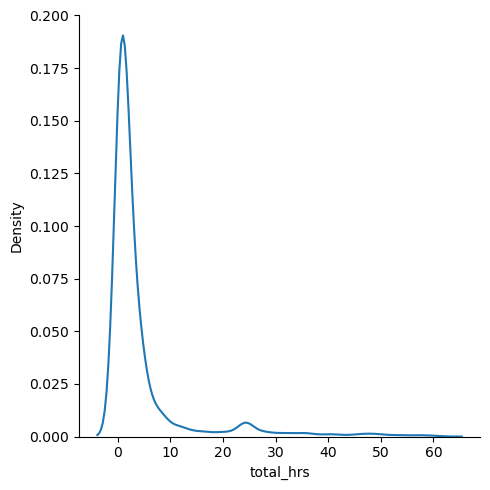

In [48]:
upper = np.percentile(df_severe.filter(pl.col("sepsis_category")==3).drop_nulls()['total_hrs'].to_numpy(), 95)
lower = np.percentile(df_severe.filter(pl.col("sepsis_category")==3).drop_nulls()['total_hrs'].to_numpy(), 5)
sns.displot(df_severe.filter(
   (pl.col("sepsis_category")==3)&
   (pl.col("total_hrs")<=upper)&
   (pl.col("total_hrs")>=lower)
).to_pandas(), x="total_hrs", kind="kde")

In [49]:
# Aggregate by the max score per encounter, and the firs start date
df_enc_severe_sep = df_severe.filter(
    pl.col("sepsis_category")>0
).sort(by="Start_DateTime").group_by("EncounterEpicCsn").agg(
    pl.col("Start_DateTime").first(),
    pl.col("sepsis_category").first().alias("first_sepsis_category"),
    #   pl.col("sepsis_category").first()
    pl.col("sepsis_category").max()
)
df_enc_severe_sep

EncounterEpicCsn,Start_DateTime,first_sepsis_category,sepsis_category
i64,datetime[μs],i32,i32
719525605,2025-01-15 22:30:00,2,2
740967921,2025-11-22 05:45:00,2,2
740144612,2025-11-10 08:30:00,3,3
732430820,2025-07-30 21:47:00,3,3
738511091,2025-10-16 14:24:00,3,3
…,…,…,…
732844630,2025-08-06 11:34:00,3,3
720393222,2025-01-30 08:06:00,3,3
722086381,2025-02-25 00:30:00,3,3


In [50]:
df_enc_severe_sep['sepsis_category'].value_counts()

sepsis_category,count
i32,u64
2,500
3,2552


In [51]:
df_enc_sirs_severe = df_enc_sirs_gte_2.join(
    df_enc_severe_sep,
    on="EncounterEpicCsn",
    how='full'
).with_columns(
    max_sep_cat=pl.when(pl.col("sepsis_category")==3).then(pl.lit("Sepsis_3")).when(pl.col("sepsis_category")==2).then(pl.lit("Sepsis_2")).otherwise(pl.lit("Sepsis_1")),
    first_sep_cat=pl.lit("Sepsis")+"_"+pl.col("first_sepsis_category").cast(pl.Utf8)
)
df_enc_sirs_severe

EncounterEpicCsn,Start_DateTime,SIRS,EncounterEpicCsn_right,Start_DateTime_right,first_sepsis_category,sepsis_category,max_sep_cat,first_sep_cat
i64,datetime[μs],f64,i64,datetime[μs],i32,i32,str,str
738511091,2025-10-16 15:15:00,2.0,738511091,2025-10-16 14:24:00,3,3,"""Sepsis_3""","""Sepsis_3"""
730649048,2025-07-02 23:25:00,2.0,null,null,null,null,"""Sepsis_1""",null
731318735,2025-07-15 00:29:00,2.0,731318735,2025-07-15 03:26:00,2,2,"""Sepsis_2""","""Sepsis_2"""
729888128,2025-06-22 10:00:00,2.0,null,null,null,null,"""Sepsis_1""",null
740670243,2025-11-17 16:05:00,2.0,null,null,null,null,"""Sepsis_1""",null
…,…,…,…,…,…,…,…,…
null,null,null,733359304,2025-08-13 20:59:00,2,3,"""Sepsis_3""","""Sepsis_2"""
null,null,null,724180601,2025-03-28 23:55:00,3,3,"""Sepsis_3""","""Sepsis_3"""
null,null,null,727183698,2025-05-10 03:30:00,3,3,"""Sepsis_3""","""Sepsis_3"""


In [52]:
df_sepsis_target = df_enc_sirs_severe.with_columns(
    pl.when(pl.col("EncounterEpicCsn").is_null()).then(pl.col("EncounterEpicCsn_right")).otherwise(pl.col("EncounterEpicCsn")).alias("EncounterEpicCsn"),
    pl.min_horizontal(["Start_DateTime", "Start_DateTime_right"]).alias("First_DateTime"),
    pl.col("first_sepsis_category").fill_null(1),
    pl.col("sepsis_category").fill_null(1),
    pl.col("first_sep_cat").fill_null("Sepsis_1"),
).select(
    "EncounterEpicCsn",
    "First_DateTime",
    "max_sep_cat",
    "first_sep_cat",
).rename({"first_sep_cat":"first_sepsis_category", "max_sep_cat": "max_sepsis_category"})


#### Ideas
- For mismatches, try to see the first severity score

In [53]:

# Old logic
# df_final.group_by("EncounterEpicCsn").agg(
#     pl.col("Original_POA_Condition").last(),
#     pl.col("Sepsis_Category").last(),
#     pl.col("Arrival_Instant").last(),
#     pl.col("Admitted_from_ED").last(),
#     pl.col("InpatientAdmissionInstant").last(),
#     pl.col("AdmittingDepartment").last(),
#     pl.col("AdmissionType").last(),
#     pl.col("AdmissionSource").last(),
#     pl.col("AdmissionOrigin").last(),
#     pl.col("PrincipalProblem").last(),
#     pl.col("Death_Flag").last(),
#     pl.col("HospitalService").last(),
# ).join(
#     df_sepsis_target,
#     on="EncounterEpicCsn",
#     how='left'
# ).with_columns(
#     pl.when(
#         pl.col("final_sep_cat")=="Sepsis_1"
# 	).then(
#         (pl.col("Start_DateTime")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True)
# 	).otherwise(
#         (pl.col("Start_DateTime_right")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True)
# 	).alias("arrival2sepsis_hrs")
# ).with_columns(
#     pl.col("final_sep_cat").fill_null("NO_SEPSIS")
# ).with_columns(
#     calculated_poa=pl.when(pl.col("arrival2sepsis_hrs")>48).then(pl.lit("N")).otherwise(pl.lit(""))
# ).with_columns(
#     (pl.col("calculated_poa")+pl.lit("POA-")+pl.col("final_sep_cat").str.split("_").list.last()).alias("calculated_poa")
# )

In [54]:
df_temp = df_final.group_by("EncounterEpicCsn").agg(
    pl.col("Original_POA_Condition").last(),
    pl.col("Sepsis_Category").last(),
    pl.col("Arrival_Instant").last(),
    pl.col("Admitted_from_ED").last(),
    pl.col("InpatientAdmissionInstant").last(),
    pl.col("AdmittingDepartment").last(),
    pl.col("AdmissionType").last(),
    pl.col("AdmissionSource").last(),
    pl.col("AdmissionOrigin").last(),
    pl.col("PrincipalProblem").last(),
    pl.col("Death_Flag").last(),
    pl.col("HospitalService").last(),
).join(
    df_sepsis_target,
    on="EncounterEpicCsn",
    how='left'
).with_columns(
	(pl.col("First_DateTime")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("arrival2sepsis_hrs")
).with_columns(
    pl.col("max_sepsis_category").fill_null("NO_SEPSIS")
).with_columns(
    calculated_poa=pl.when(pl.col("arrival2sepsis_hrs")>48).then(pl.lit("N")).otherwise(pl.lit(""))
).with_columns(
    (pl.col("calculated_poa")+pl.lit("POA-")+pl.col("max_sepsis_category").str.split("_").list.last()).alias("calculated_poa")
).with_columns(
    pl.when(pl.col("calculated_poa")=="POA-SEPSIS").then(pl.lit("NO-SEPSIS")).otherwise(pl.col("calculated_poa")).alias("calculated_poa")
)

In [55]:
df_final.group_by("EncounterEpicCsn").agg(pl.col('Sepsis_Category').last())['Sepsis_Category'].value_counts().sort(by='Sepsis_Category')

Sepsis_Category,count
str,u64
"""NPOA-1""",217
"""NPOA-2""",44
"""NPOA-3""",302
"""POA-1""",1681
"""POA-2""",775
"""POA-3""",862
"""UPOA-1""",617
"""UPOA-2""",76
"""UPOA-3""",78


In [56]:
df_temp['calculated_poa'].value_counts().sort(by="calculated_poa")

calculated_poa,count
str,u64
"""NO-SEPSIS""",127
"""NPOA-1""",52
"""NPOA-2""",11
"""NPOA-3""",93
"""POA-1""",1421
"""POA-2""",489
"""POA-3""",2459


In [57]:
df_temp.filter(pl.col("calculated_poa")=="NO-SEPSIS").filter(pl.col("Original_POA_Condition")=="NPOA-3")

EncounterEpicCsn,Original_POA_Condition,Sepsis_Category,Arrival_Instant,Admitted_from_ED,InpatientAdmissionInstant,AdmittingDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,Death_Flag,HospitalService,First_DateTime,max_sepsis_category,first_sepsis_category,arrival2sepsis_hrs,calculated_poa
i64,str,str,datetime[μs],str,datetime[μs],str,str,str,str,str,i64,str,datetime[μs],str,str,f64,str
743266312,"""NPOA-3""","""NPOA-3""",2025-12-26 12:32:00,"""Yes""",2025-12-26 16:58:00,"""UH 12O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Obstructive jaundice due to ca…",0,"""Oncology - Solid Tumor""",null,"""NO_SEPSIS""",null,null,"""NO-SEPSIS"""
727626519,"""NPOA-3""","""UPOA-3""",2025-05-16 13:01:00,"""No""",2025-05-16 13:01:00,"""UH 08B MICU""","""Urgent""","""Trans from Hospital Owned Acut…","""Direct Admission""","""*Unspecified""",0,"""Palliative Care """,null,"""NO_SEPSIS""",null,null,"""NO-SEPSIS"""
724472037,"""NPOA-3""","""UPOA-3""",2025-04-01 15:30:00,"""No""",2025-04-01 15:30:00,"""UH 07B ICU""","""Urgent""","""Trans from Hospital Owned Acut…","""Direct Admission""","""*Unspecified""",1,"""MICU""",null,"""NO_SEPSIS""",null,null,"""NO-SEPSIS"""
744118433,"""NPOA-3""","""NPOA-3""",2026-01-10 11:03:00,"""No""",2026-01-10 11:03:00,"""ZL 8TH FL""","""Elective""","""Trans from Short Term General …","""Transfer Center Admission""","""Small bowel perforation (*)""",0,"""Physical Medicine & Rehabilita…",null,"""NO_SEPSIS""",null,null,"""NO-SEPSIS"""
732979336,"""NPOA-3""","""UPOA-3""",2025-08-07 21:22:00,"""Yes""",2025-08-08 04:01:00,"""*Unspecified""","""Emergency""","""Home & Outside Location""","""Unknown Admission Type""","""Malfunction of nephrostomy tub…",0,"""Hospital Medicine""",null,"""NO_SEPSIS""",null,null,"""NO-SEPSIS"""
743202790,"""NPOA-3""","""UPOA-3""",2025-12-24 14:57:00,"""No""",2025-12-24 14:57:00,"""ZL 8TH FL""","""Elective""","""Trans from Short Term General …","""Transfer Center Admission""","""Severe sepsis with septic shoc…",0,"""Physical Medicine & Rehabilita…",null,"""NO_SEPSIS""",null,null,"""NO-SEPSIS"""
733229914,"""NPOA-3""","""UPOA-3""",2025-08-14 18:27:00,"""No""",2025-08-14 18:27:00,"""UH 10G""","""Elective""","""Home & Outside Location""","""Direct Admission""","""*Unspecified""",0,"""Lung Transplant""",null,"""NO_SEPSIS""",null,null,"""NO-SEPSIS"""


In [58]:
col_true = "Sepsis_Category"
col_pred = "calculated_poa"
df_cm = (
    df_temp
    .group_by([col_true, col_pred])
    .len()
    .pivot(
        values="len",
        index=col_true,
        columns=col_pred
    )
    .fill_null(0)
    .sort(col_true)
).with_columns(
    pl.lit(0).alias("UPOA-1"),
    pl.lit(0).alias("UPOA-2"),
    pl.lit(0).alias("UPOA-3"),
)
cm_pd = df_cm.to_pandas().set_index(col_true)
cm_pd.loc[:, cm_pd.index.to_list()+["NO-SEPSIS"]]

/tmp/ipykernel_2306555/3124751317.py:4: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_temp


,NPOA-1,NPOA-2,NPOA-3,POA-1,POA-2,POA-3,UPOA-1,UPOA-2,UPOA-3,NO-SEPSIS
Sepsis_Category,,,,,,,,,,
NPOA-1,16,7,22,42,17,113,0,0,0,0
NPOA-2,1,0,6,3,3,31,0,0,0,0
NPOA-3,2,0,32,4,14,248,0,0,0,2
POA-1,11,3,8,802,203,612,0,0,0,42
POA-2,5,0,3,247,119,395,0,0,0,6
POA-3,0,0,4,53,59,744,0,0,0,2
UPOA-1,15,1,15,242,55,225,0,0,0,64
UPOA-2,1,0,1,17,13,38,0,0,0,6
UPOA-3,1,0,2,11,6,53,0,0,0,5


In [59]:
df_final.filter(
    pl.col("EncounterEpicCsn")==743229399
).tail(10)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,Start_DateTime,End_DateTime,SIRS,Start_DateTime_severity,End_DateTime_severity,Severe_Sepsis,Septic_Shock
i64,datetime[μs],str,str,str,str,str,str,i64,str,str,datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,datetime[μs],str,i64,i64,i64,f64,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,datetime[μs],datetime[μs],i64,i64
743229399,2025-12-25 23:59:00,"""Flowsheet""","""Pulse""","""PULSE""","""109.0""","""109""",null,98836055,"""2025-12-25""","""2025-12-26""",2025-12-25 01:03:00,2025-12-25 04:27:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""ZL 7TH FL""","""ZL 7TH FL""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis due to Salmonella speci…","""Salmonella sepsis (*)""","""*Unspecified""",0,"""POA-1""","""POA-1""",2025-12-25 02:35:00,"""Code Sepsis Order""",null,null,null,0.7,322.0,0.7,125.0,10.69,2025-12-25 05:08:00,2025-12-26 04:56:00,4.0,2025-12-25 19:41:00,2025-12-26 04:20:00,0,0
743229399,2025-12-26 02:00:48,"""Diagnosis Event""","""Hospital Problem""","""Salmonella bacteremia""",null,"""R78.81""",null,98836055,"""2025-12-25""","""2025-12-26""",2025-12-25 01:03:00,2025-12-25 04:27:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""ZL 7TH FL""","""ZL 7TH FL""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis due to Salmonella speci…","""Salmonella sepsis (*)""","""*Unspecified""",0,"""POA-1""","""POA-1""",2025-12-25 02:35:00,"""Code Sepsis Order""",null,null,null,0.7,322.0,0.7,125.0,10.69,2025-12-25 05:08:00,2025-12-26 04:56:00,4.0,2025-12-25 19:41:00,2025-12-26 04:20:00,0,0
743229399,2025-12-25 04:15:00,"""Flowsheet""","""Systolic Blood Pressure""","""BLOOD PRESSURE""","""91""","""91/64""",null,98836055,"""2025-12-25""","""2025-12-26""",2025-12-25 01:03:00,2025-12-25 04:27:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""ZL 7TH FL""","""ZL 7TH FL""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis due to Salmonella speci…","""Salmonella sepsis (*)""","""*Unspecified""",0,"""POA-1""","""POA-1""",2025-12-25 02:35:00,"""Code Sepsis Order""",null,null,null,0.7,322.0,0.7,125.0,10.69,2025-12-25 04:08:00,2025-12-25 05:08:00,3.0,2025-12-25 01:07:00,2025-12-25 05:08:00,0,0
743229399,2025-12-26 04:20:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""","""18.0""","""18""",null,98836055,"""2025-12-25""","""2025-12-26""",2025-12-25 01:03:00,2025-12-25 04:27:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""ZL 7TH FL""","""ZL 7TH FL""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis due to Salmonella speci…","""Salmonella sepsis (*)""","""*Unspecified""",0,"""POA-1""","""POA-1""",2025-12-25 02:35:00,"""Code Sepsis Order""",null,null,null,0.7,322.0,0.7,125.0,10.69,2025-12-25 05:08:00,2025-12-26 04:56:00,4.0,2025-12-26 04:20:00,2025-12-26 05:45:00,0,1
743229399,2025-12-25 08:10:00,"""Flowsheet""","""Gastrointestinal Assessment""","""CPM S25 R AS GASTROINTESTINAL …",null,"""X;GI symptoms""",null,98836055,"""2025-12-25""","""2025-12-26""",2025-12-25 01:03:00,2025-12-25 04:27:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""ZL 7TH FL""","""ZL 7TH FL""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis due to Salmonella s

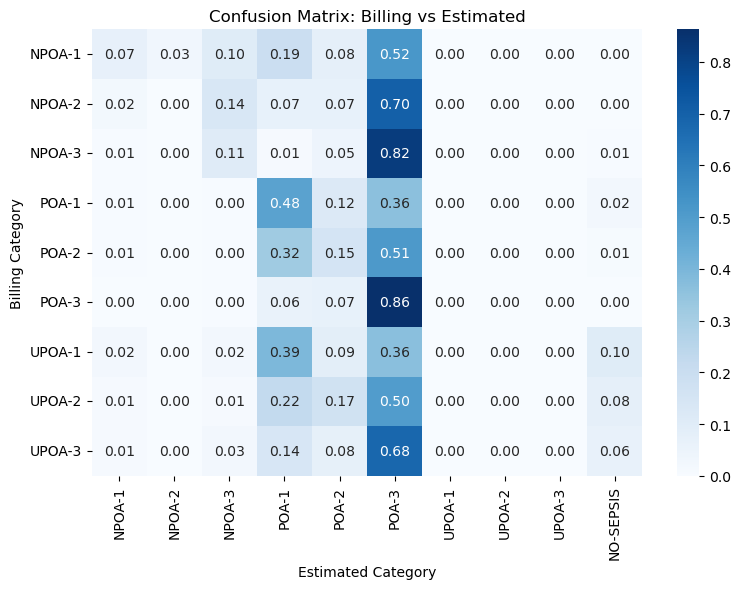

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
cm_pd = cm_pd.loc[:, cm_pd.index.to_list()+["NO-SEPSIS"]]
cm_col_norm = cm_pd.div(cm_pd.sum(axis=0), axis=1)
cm_row_norm = cm_pd.div(cm_pd.sum(axis=1), axis=0)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_row_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Confusion Matrix: Billing vs Estimated")
plt.ylabel("Billing Category")
plt.xlabel("Estimated Category")
plt.tight_layout()
plt.show()


In [61]:
ORDER_COLS = ["POA-1", "POA-2", "POA-3", "NPOA-1", "NPOA-2", "NPOA-3"]
def plot_per_group(df, variable="AdmittingDepartment", target="Original_POA_Condition", max_cat_len=70):

	grb = df.group_by("EncounterEpicCsn").agg(
		pl.col("Sepsis_Category").last(),
		pl.col("calculated_poa").last(),
		pl.col("AdmissionType").last(),
		pl.col("AdmissionSource").last(),
		pl.col("Arrival_Instant").last(),
		pl.col("Admitted_from_ED").last(),
		pl.col("InpatientAdmissionInstant").last(),
		pl.col("AdmittingDepartment").last(),
		pl.col("AdmissionOrigin").last(),
		pl.col("PrincipalProblem").last(),
		pl.col("Death_Flag").last(),
		pl.col("HospitalService").last(),
	).group_by([target, variable]).agg(pl.len()).sort(by='len')
	grb_cnt = grb.group_by([variable, target]).agg(pl.sum("len").alias("count"))
	if len(grb_cnt)>max_cat_len:
		grb_cnt = grb_cnt.sort(by="count", descending=True).head(max_cat_len)
	df_pivot = (
		grb_cnt.pivot(
			values="count",
			index=variable,
			columns=target
		)
		.fill_null(0)
	)
	cols2del = []
	for c in ORDER_COLS:
		if c not in df_pivot.columns:
			cols2del.append(c)
	
	filtered_cols = [x for x in ORDER_COLS if x not in cols2del]
     
	df_pivot = df_pivot.select([variable]+filtered_cols)
	pdf = df_pivot.to_pandas().set_index(variable)
	pdf['total'] = pdf.sum(axis=1)
	icu_pat = re.compile(r"(ICU|MICU|SICU|CVICU|NEURO ICU|NICU)", re.IGNORECASE)

	def dept_rank(name: str):
		if name is None:
			return (99, "")
		if name == "*Unspecified":
			return (98, name)
		if icu_pat.search(str(name)):
			return (0, str(name))
		return (2, str(name))

	order = sorted(pdf.index.tolist(), key=dept_rank)
	pdf = pdf.reindex(order)	
	pdf.index = [
		x[:40] + "..." if len(x) > 40 else x
		for x in pdf.index
	]	
	# pdf.sort_values(by="total", ascending=False).drop(columns="total").plot(
	if "department" in variable.lower():
		pdf.drop(columns="total").plot(
			kind="bar",
			stacked=True,
			figsize=(14, 8)
		)
	else:
		pdf.sort_values(by="total", ascending=False).drop(columns="total").plot(
			kind="bar",
			stacked=True,
			figsize=(14, 8)
		)

	plt.ylabel("Number of Encounters")
	plt.title(f"{target} Distribution by {variable}")
	plt.xticks(rotation=90)
	plt.tight_layout()
	plt.show()
	import seaborn as sns
	pdf_color = (pdf - pdf.min()) / (pdf.max() - pdf.min())
	pdf_color = pdf_color.fillna(0)


	plt.figure(figsize=(12, 10))
	sns.heatmap(pdf_color.sort_values(by="total", ascending=False).drop(columns="total"), annot=False, cmap="Blues")
	plt.title("POA Condition by Admitting Department")
	plt.show()

In [62]:
df_temp.filter(pl.col("Sepsis_Category")=="NPOA-2")['PrincipalProblem'].value_counts().sort(by='count', descending=True).head(10).to_pandas()

,PrincipalProblem,count
0,*Unspecified,3
1,"Shock, cardiogenic (*)",2
2,Right-sided nontraumatic intracerebral hemorrh...,1
3,Kidney transplant recipient,1
4,Acute respiratory failure with hypoxia and hyp...,1
5,CNS lymphoma (*),1
6,Stroke (*),1
7,Acute myeloid leukemia not having achieved rem...,1
8,Cholecystitis,1
9,SOB (shortness of breath),1


/tmp/ipykernel_2306555/2335511330.py:22: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  grb_cnt.pivot(


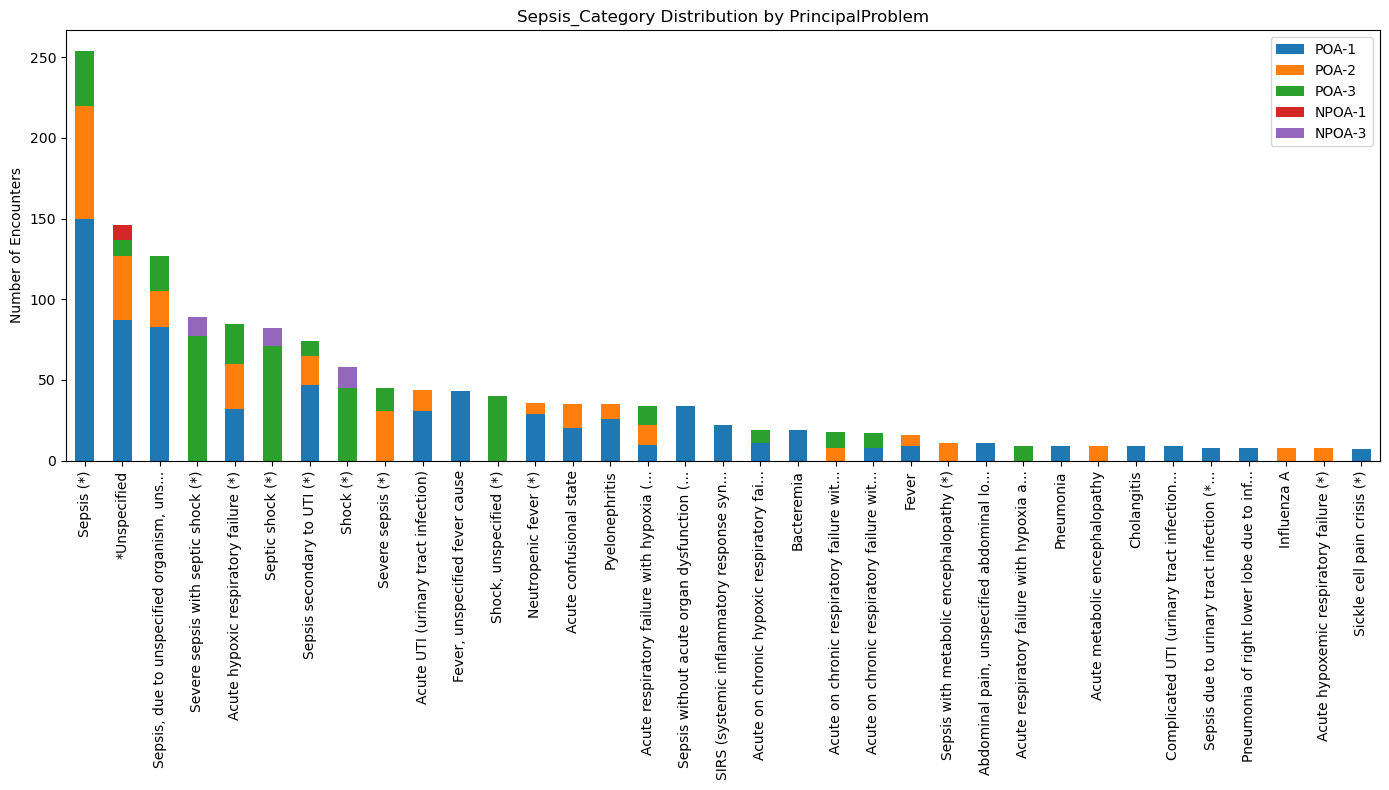

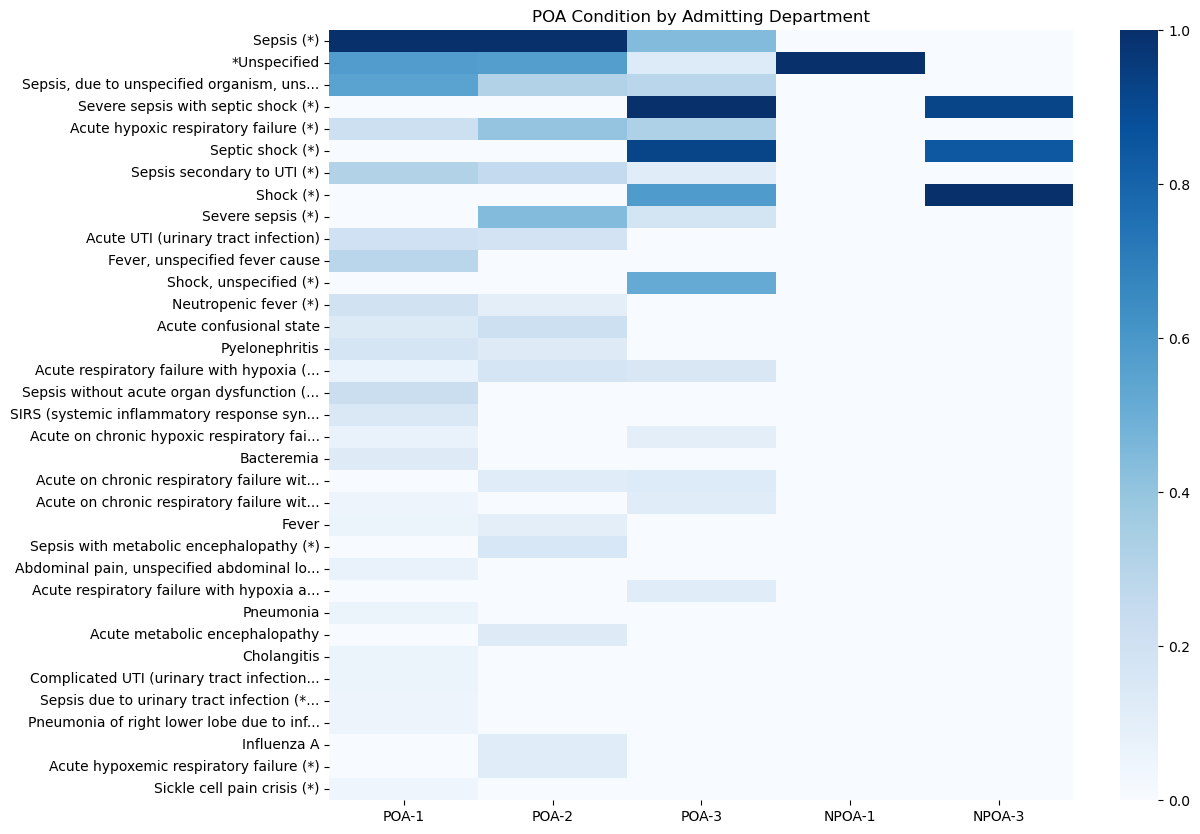

In [63]:
plot_per_group(df_temp, "PrincipalProblem", "Sepsis_Category")

/tmp/ipykernel_2306555/2335511330.py:22: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  grb_cnt.pivot(


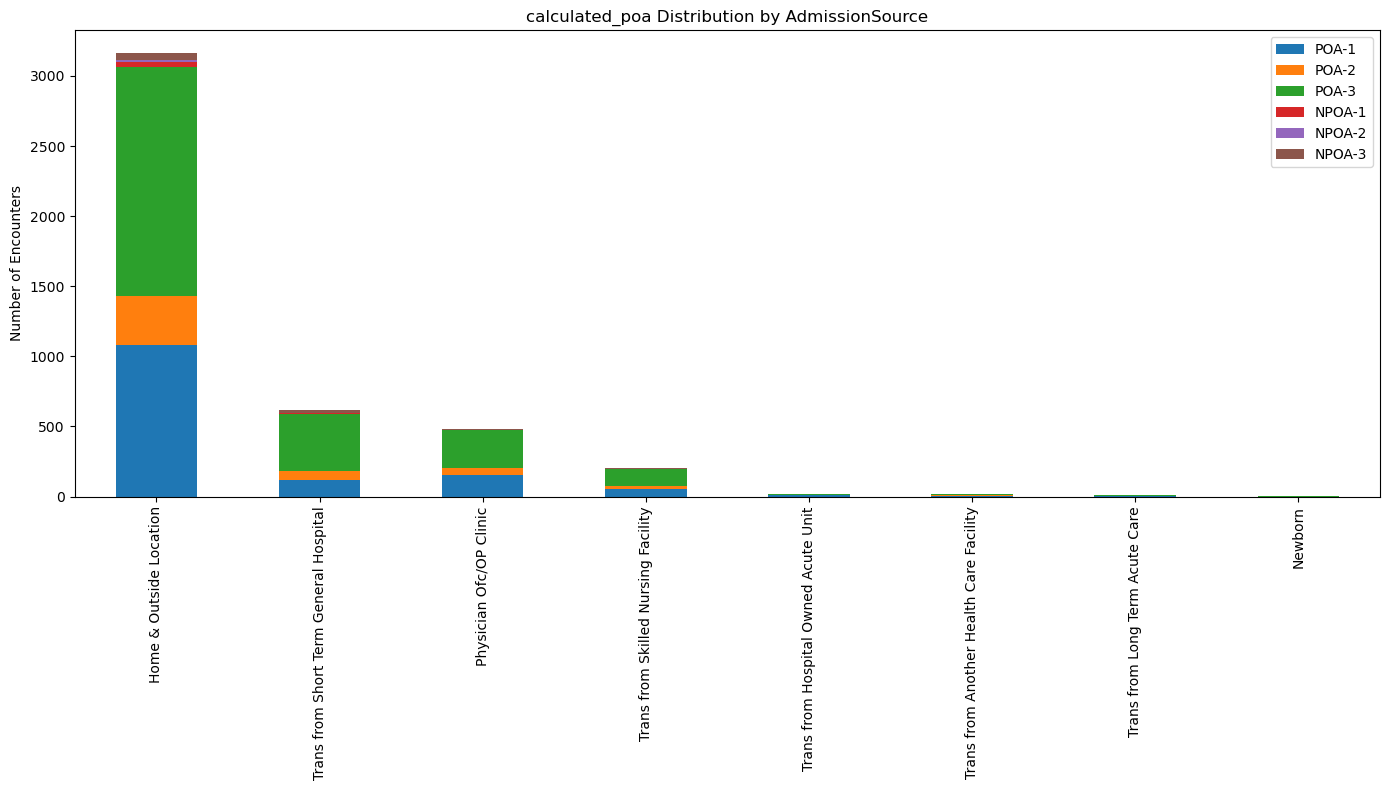

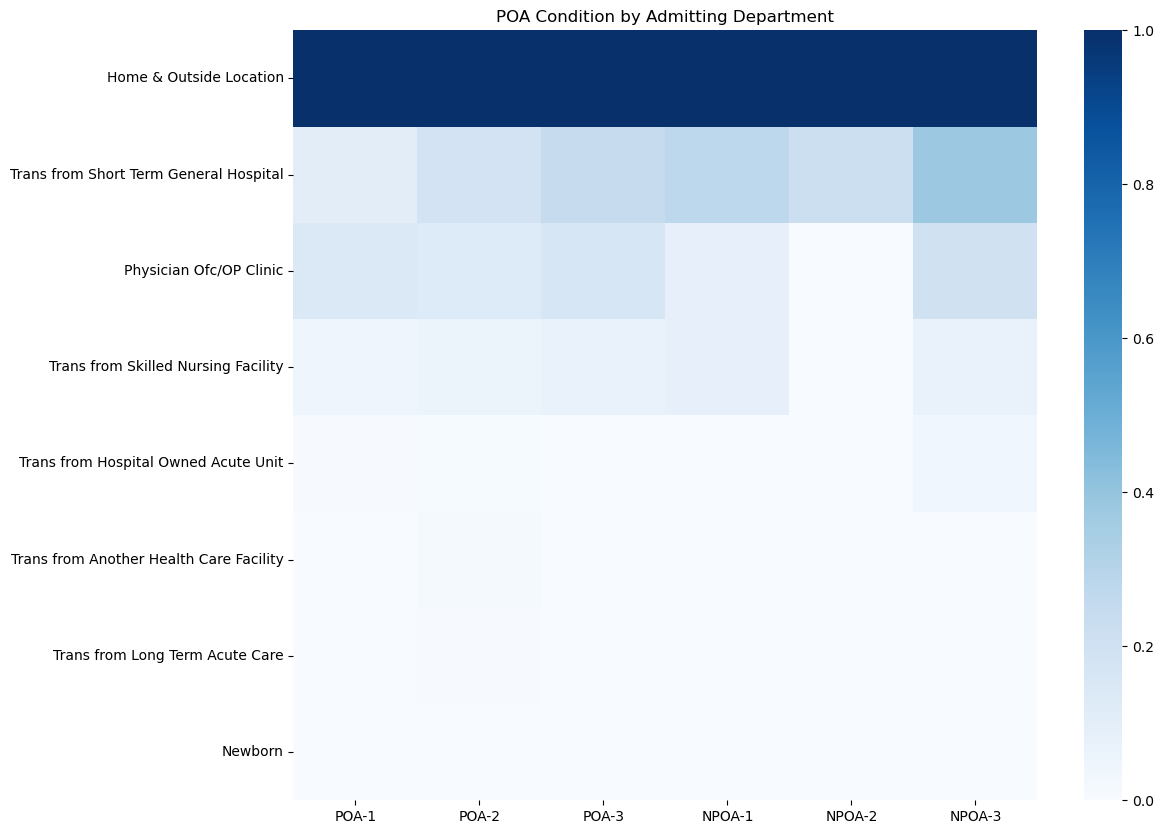

In [64]:
plot_per_group(df_temp, "AdmissionSource", "calculated_poa")

/tmp/ipykernel_2306555/2335511330.py:22: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  grb_cnt.pivot(


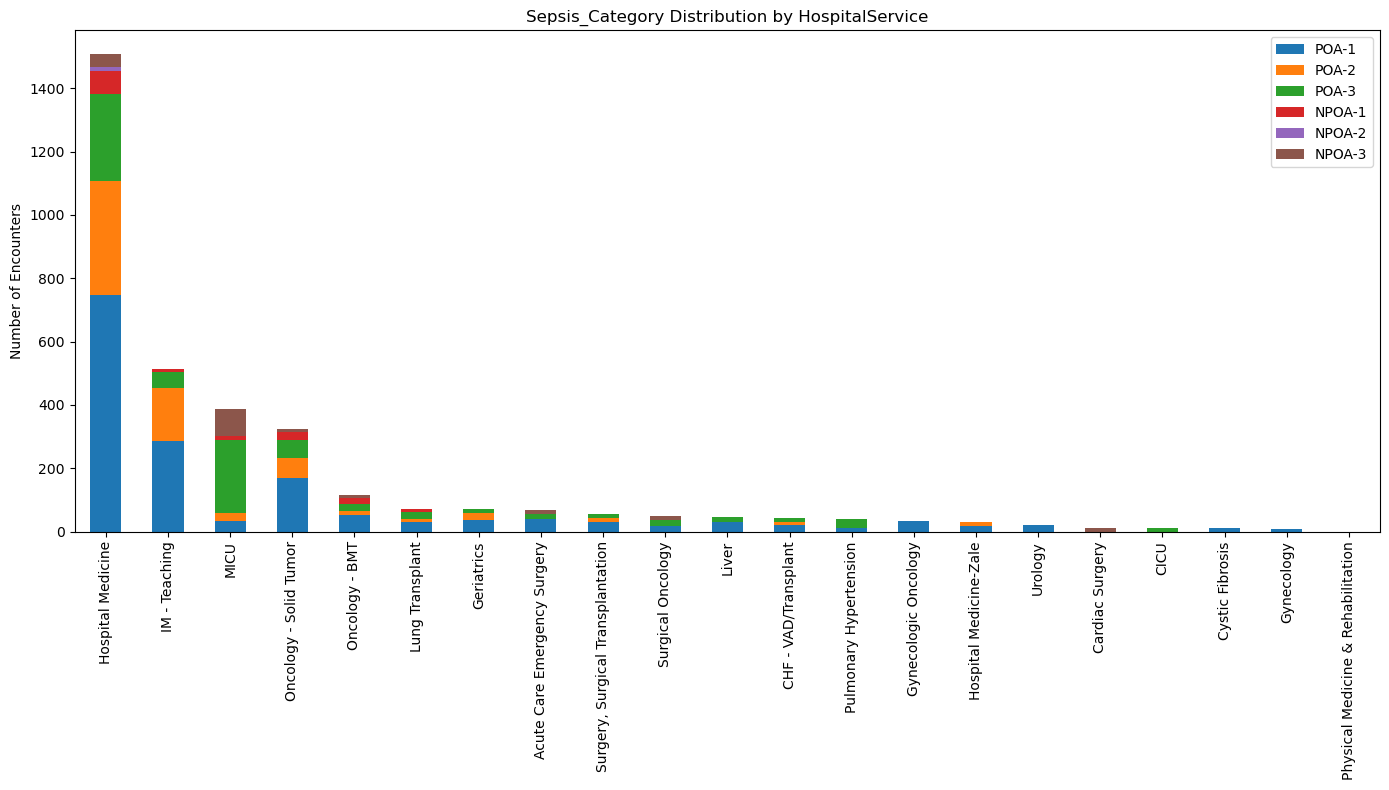

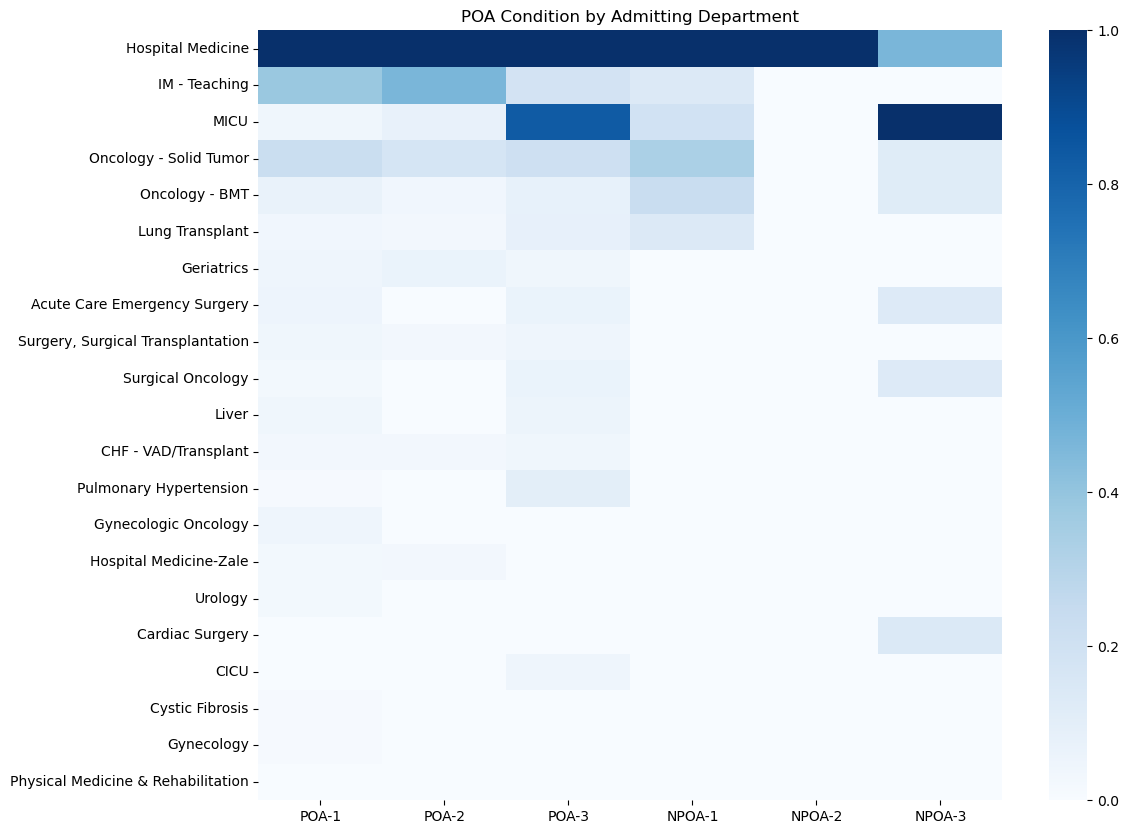

In [65]:
plot_per_group(df_temp, "HospitalService", "Sepsis_Category")

/tmp/ipykernel_2306555/2335511330.py:22: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  grb_cnt.pivot(


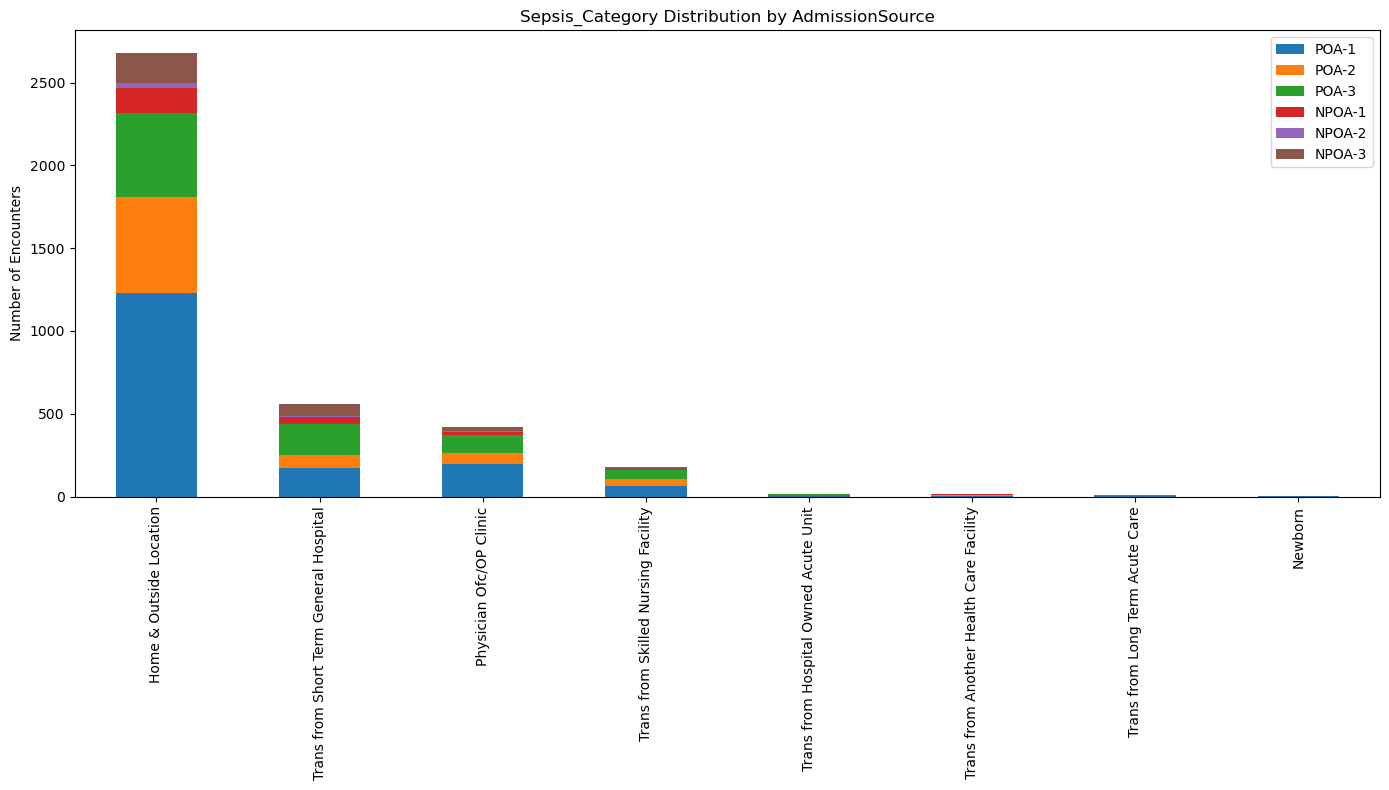

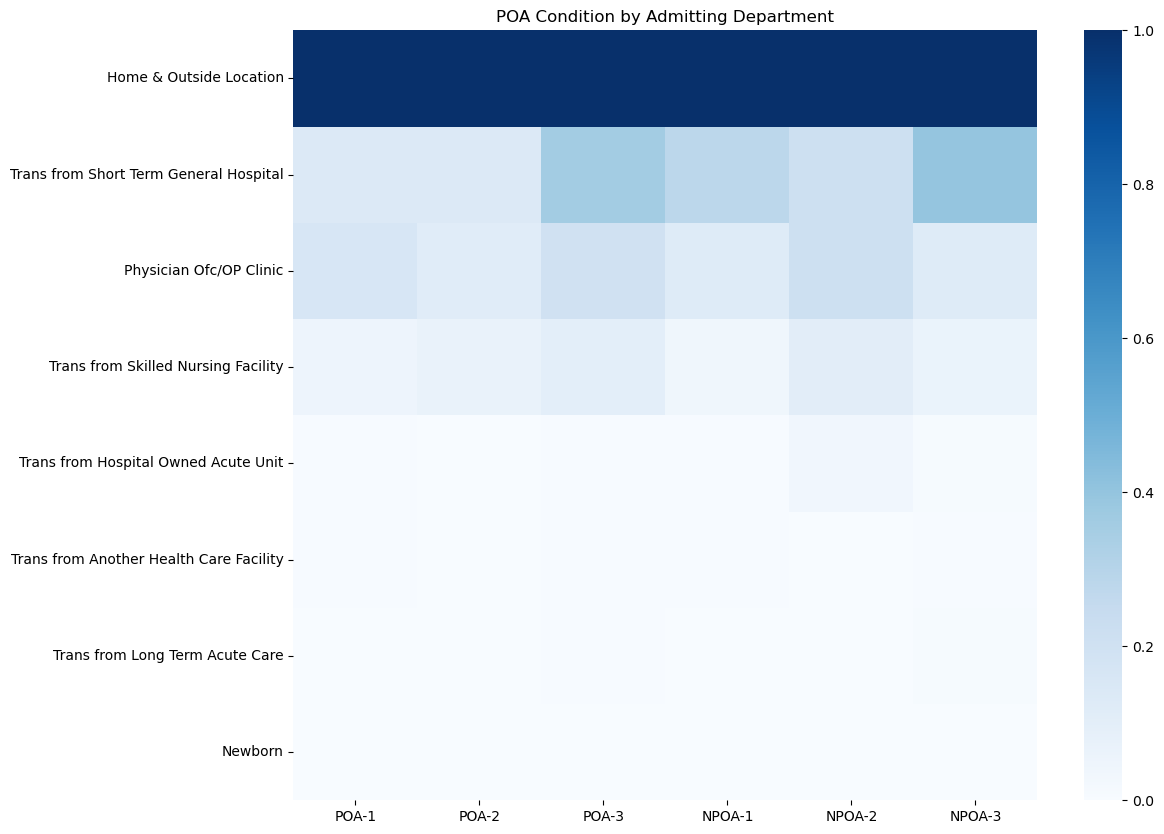

In [66]:
plot_per_group(df_temp, "AdmissionSource", "Sepsis_Category")

In [67]:
pl.col("Sepsis_Category").last(),
pl.col("calculated_poa").last(),
pl.col("AdmissionType").last(),
pl.col("AdmissionSource").last(),
pl.col("Arrival_Instant").last(),
pl.col("Admitted_from_ED").last(),
pl.col("InpatientAdmissionInstant").last(),
pl.col("AdmittingDepartment").last(),
pl.col("AdmissionOrigin").last(),
pl.col("PrincipalProblem").last(),
pl.col("Death_Flag").last(),
pl.col("HospitalService").last(),

(<Expr ['col("HospitalService").last()'] at 0x7F92208BF280>,)

In [69]:
df_severe_updated

PrimaryMrn,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,Suspected Infection Time,Sepsis Time,Severe Sepsis Time,Septic Shock Time,Sepsis Exists,Severe Sepsis Exists,Septic Shock Exists,Calculated
i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,i64,i64,i64,f64,f64,f64,f64,f64,str,str,str,str,i64,i64,i64,str
97954053,724491843,"""4/2/2025""","""4/14/2025""","""4/2/25 8:00 AM""","""4/2/25 8:00 AM""","""No""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 08B MICU""","""UH 06O""","""Emergency""","""Trans from Short Term General …","""Transfer Center Admission""","""Acute hyponatremia""","""Hypo-osmolality and hyponatrem…","""Drainage of Stomach with Drain…",0,"""NPOA-1""","""NPOA-1""",125,17,81,1.320667,21.4,1.215385,60.0,4.752667,"""4/11/25 2:40 AM""","""4/2/25 3:00 PM""","""4/6/25 5:42 AM""",null,1,1,0,"""POA - 2"""
93597754,724708521,"""4/4/2025""","""4/11/2025""","""4/4/25 12:57 PM""","""4/4/25 5:29 PM""","""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 12G""","""UH 12G""","""Emergency""","""Trans from Skilled Nursing Fac…","""ED Admission""","""Tardive dyskinesia""","""Drug induced subacute dyskines…","""*Unspecified""",0,"""POA-1""","""POA-1""",null,null,null,null,null,null,null,null,"""4/4/25 10:15 PM""","""4/4/25 5:47 PM""",null,null,1,0,0,"""POA - 1"""
92654311,724734100,"""4/4/2025""","""4/9/2025""","""4/4/25 5:22 PM""","""4/5/25 4:51 PM""","""Yes""","""Inpatient""","""Observation""","""IM - Teaching""","""UH 10G""","""UH 10G""","""Emergency""","""Physician Ofc/OP Clinic""","""ED Admission""","""Neutropenic fever (*)""","""Other gram-negative sepsis (*)""","""*Unspecified""",0,"""POA-1""","""POA-1""",106,17,94,0.565429,95.3125,0.811111,116.0,27.687083,"""4/4/25 5:30 PM""","""4/5/25 4:31 AM""",null,null,1,0,0,"""POA - 1"""
70082266,724754090,"""4/6/2025""","""4/11/2025""","""4/6/25 1:24 PM""","""4/6/25 9:15 PM""","""Yes""","""Inpatient""","""Emergency""","""Hospital Medicine""","""UH 12O""","""UH 12O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis (*)""","""Sepsis, unspecified organism (…","""*Unspecified""",0,"""POA-2""","""POA-2""",null,null,null,null,null,null,null,null,"""4/6/25 2:43 PM""","""4/6/25 2:05 PM""",null,null,1,0,0,"""POA - 1"""
94097220,724755525,"""4/6/2025""","""4/12/2025""","""4/6/25 11:49 PM""","""4/6/25 11:49 PM""","""No""","""Inpatient""","""Inpatient""","""Lung Transplant""","""UH 10B HRT LNG""","""UH 10B HRT LNG""","""Urgent""","""Trans from Short Term General …","""Transfer Center Admission""","""Severe sepsis without septic s…","""Fever, unspecified""","""Excision of Right Lower Lung L…",0,"""NPOA-2""","""UPOA-2""",104,14,83,1.806471,135.75,1.275,41.444444,7.364375,"""4/7/25 2:45 AM""","""4/7/25 11:35 AM""","""4/7/25 6:18 AM""",null,1,1,0,"""POA - 2"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
74108352,743062434,"""12/22/2025""","""1/1/2026""","""12/22/25 1:58 PM""","""12/22/25 5:25 PM""","""Yes""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 08G""","""UH 07B ICU""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Bacteremia associated with int…","""Bloodstream infection due to c…","""Respiratory Ventilation, Great…",1,"""POA-3""","""POA-3""",136,17,105,0.98,220.0,0.45,74.75,9.658333,"""12/22/25 2:44 PM""","""12/22/25 2:41 PM""","""12/22/25 3:51 PM""","""12/26/25 10:55 AM""",1,1,1,"""POA - 3"""
95997124,743087089,"""12/22/2025""","""1/7/2026""","""12/22/25 8:42

In [91]:
df_enc_severe_sep.shape, df_enc_sirs_gte_2.shape

((3052, 3), (3865, 3))

In [ ]:
df_severe.with_columns(
    (pl.col("Severe_Sepsis")+pl.col("Septic_Shock")).alias("total")
).filter(
    (pl.col("Septic_Shock")==1)& (pl.col("sepsis_category")==3)
)
# df_sever.filter(pl.col("Septic_Shock")==1).sort(by="Start_DateTime").drop_nulls()

EncounterEpicCsn,Start_DateTime,End_DateTime,Severe_Sepsis,Septic_Shock,total_hrs,hrs_before_next_state,sepsis_category,total
i64,datetime[μs],datetime[μs],i64,i64,f64,f64,i32,i64
699476058,2024-04-30 21:58:00,2024-04-30 22:05:00,1,1,0.116667,0.0,3,2
699476058,2024-04-30 22:16:00,2025-10-31 14:55:00,1,1,13168.65,0.0,3,2
707748493,2024-08-23 04:21:00,2024-08-23 05:00:00,0,1,0.65,0.0,3,1
707748493,2024-08-24 19:00:00,2024-08-25 00:45:00,1,1,5.75,0.0,3,2
707748493,2024-08-25 02:45:00,2024-08-25 03:00:00,1,1,0.25,0.0,3,2
…,…,…,…,…,…,…,…,…
745052798,2026-01-29 16:00:00,2026-01-29 16:30:00,0,1,0.5,0.0,3,1
745052798,2026-01-29 18:00:00,2026-01-29 19:00:00,0,1,1.0,0.0,3,1
745052798,2026-01-29 21:00:00,2026-01-29 23:00:00,0,1,2.0,0.0,3,1


In [26]:
df_final.group_by("EncounterEpicCsn").agg(
    pl.col('InpatientAdmissionPatientClass').first().alias('first'),
    pl.col('InpatientAdmissionPatientClass').last().alias('last')
).filter(pl.col("first")!=pl.col("last"))
df_final['InpatientAdmissionPatientClass'].value_counts()

InpatientAdmissionPatientClass,count
str,u64
"""Emergency""",218941
"""Inpatient""",5100836
"""Outpatient""",50490
"""*Unspecified""",3404
"""Observation""",852364


In [198]:
df_final.with_columns(
    [(pl.col("Severe_Sepsis")+pl.col("Septic_Shock")).alias("total_sepsis"),
    pl.when(pl.col("SIRS")>=2).then(pl.lit(1)).otherwise(pl.lit(0)).alias("sepsis_1")]
).group_by(
    "EncounterEpicCsn"
).agg(
    pl.col("sepsis_1").max(),
    pl.col("Severe_Sepsis").max(),
    pl.col("Septic_Shock").max(),
).filter(pl.col("sepsis_1")==0)

EncounterEpicCsn,sepsis_1,Severe_Sepsis,Septic_Shock
i64,i32,i64,i64
729888128,0,0,0
725156279,0,0,0
725728966,0,0,0
724996491,0,1,0
728673413,0,0,0
…,…,…,…
739243429,0,0,0
728684551,0,0,0
728026267,0,0,0


In [199]:
df_final.select(
	"EncounterEpicCsn",
    "Original_POA_Condition",
    "Sepsis_Category",
    "Severe_Sepsis",
    "Septic_Shock"
)

EncounterEpicCsn,Original_POA_Condition,Sepsis_Category,Severe_Sepsis,Septic_Shock
i64,str,str,i64,i64
717006646,"""NPOA-3""","""NPOA-3""",1,1
733704050,"""NPOA-1""","""NPOA-1""",0,0
695960811,"""NPOA-3""","""NPOA-3""",0,0
724205477,"""POA-1""","""POA-1""",0,1
728105178,"""NPOA-3""","""NPOA-3""",0,1
…,…,…,…,…
722954305,"""POA-2""","""POA-2""",1,1
722697899,"""NPOA-3""","""NPOA-3""",0,0
727206012,"""POA-2""","""POA-2""",1,0


In [200]:
df_final.group_by(
    "EncounterEpicCsn"
).agg(
    pl.col("Original_POA_Condition").first().alias("forigpoa"),
    pl.col("Original_POA_Condition").last().alias("lorigpoa"),
    pl.col("Sepsis_Category").first().alias("fsep"),
    pl.col("Sepsis_Category").last().alias("lsep"),
).filter(pl.col("fsep")!=pl.col("lsep"))

EncounterEpicCsn,forigpoa,lorigpoa,fsep,lsep
i64,str,str,str,str


In [201]:
ORDER_COLS=["UPOA-1", "UPOA-2", "UPOA-3", "NPOA-1", "NPOA-2", "NPOA-3", "POA-1", "POA-2", "POA-3"]
df_conf = (
    df_final.group_by("EncounterEpicCsn").agg(
        pl.col("Original_POA_Condition").first(),
        pl.col("Sepsis_Category").first(),
	).group_by([
        "Original_POA_Condition",
        "Sepsis_Category"
	]).len().rename({"len":"n"}).pivot(
        values="n",
        index="Original_POA_Condition",
        columns="Sepsis_Category",
	).fill_null(0).sort("Original_POA_Condition")
).select(["Original_POA_Condition"]+ORDER_COLS)
df_conf

/tmp/ipykernel_3367039/2144998276.py:3: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_final.group_by("EncounterEpicCsn").agg(


Original_POA_Condition,UPOA-1,UPOA-2,UPOA-3,NPOA-1,NPOA-2,NPOA-3,POA-1,POA-2,POA-3
str,u64,u64,u64,u64,u64,u64,u64,u64,u64
"""NPOA-1""",617,0,0,206,0,0,0,0,0
"""NPOA-2""",0,76,0,6,42,0,0,0,0
"""NPOA-3""",0,0,78,5,2,302,0,0,0
"""POA-1""",0,0,0,0,0,0,1681,86,135
"""POA-2""",0,0,0,0,0,0,0,689,19
"""POA-3""",0,0,0,0,0,0,0,0,708


In [202]:
sum([617,	76, 	78	,206,	6,	5, 42,2,	301	,1681,	86, 689, 135, 19, 708])


4651

In [28]:
df_final.columns

['EncounterEpicCsn',
 'Event_DateTime',
 'Type',
 'Event_Grouper',
 'Event_Name',
 'NumericValue',
 'Value',
 'Flag',
 'PrimaryMrn',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'Start_DateTime',
 'End_DateTime',
 'SIRS',
 'Start_DateTime_severity',
 'End_DateTime_severity',
 'Severe_Sepsis',
 'Septic_Shock']

In [203]:
df_conf_pct = df_conf.with_columns(
    (pl.all().exclude("Original_POA_Condition") / 
     pl.sum_horizontal(pl.all().exclude("Original_POA_Condition")))
    .round(3)
)
df_conf_pct

Original_POA_Condition,UPOA-1,UPOA-2,UPOA-3,NPOA-1,NPOA-2,NPOA-3,POA-1,POA-2,POA-3
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""NPOA-1""",0.75,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0
"""NPOA-2""",0.0,0.613,0.0,0.048,0.339,0.0,0.0,0.0,0.0
"""NPOA-3""",0.0,0.0,0.202,0.013,0.005,0.78,0.0,0.0,0.0
"""POA-1""",0.0,0.0,0.0,0.0,0.0,0.0,0.884,0.045,0.071
"""POA-2""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.973,0.027
"""POA-3""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [40]:
from sklearn.metrics import cohen_kappa_score

df_grb = (
    df_final.group_by("EncounterEpicCsn").agg(
        pl.col('Original_POA_Condition').first(),
        pl.col('Sepsis_Category').first(),
	)
)

kappa = cohen_kappa_score(
    df_grb["Original_POA_Condition"].to_list(),
    df_grb["Sepsis_Category"].to_list()
)
kappa

0.719520193359309

In [ ]:
df_final.group_by("EncounterEpicCsn").agg(
    pl.col("Original_POA_Condition").last(),
    pl.col("Sepsis_Category").last(),
).with_columns(
    (pl.col("Original_POA_Condition")==pl.col("Sepsis_Category")).cast(pl.Int64).alias("match")
)["match"].sum(), df_final['EncounterEpicCsn'].n_unique()

(3628, 4652)

In [35]:
3628/4652

0.7798796216680998

In [205]:
print(
    """
Kappa measures inter-rater agreement for categorical items, adjusting for chance. It ranges from -1 to 1, where 1 is perfect agreement, 0 is agreement equal to chance, and \(<0\) indicates agreement worse than chance. Generally, values \(>0.60\) or \(>0.75\) are considered substantial/good agreement, with \(>0.81\) considered almost perfect. 
    """
)


Kappa measures inter-rater agreement for categorical items, adjusting for chance. It ranges from -1 to 1, where 1 is perfect agreement, 0 is agreement equal to chance, and \(<0\) indicates agreement worse than chance. Generally, values \(>0.60\) or \(>0.75\) are considered substantial/good agreement, with \(>0.81\) considered almost perfect. 
    


Q2: Merge UPOA-s with NPOA-s and analyze the data

In [41]:
df_final = df_final.with_columns(
    pl.when(pl.col("Sepsis_Category")=='UPOA-1').then(pl.lit("NPOA-1"))
    .when(pl.col("Sepsis_Category")=='UPOA-2').then(pl.lit("NPOA-2"))
    .when(pl.col("Sepsis_Category")=='UPOA-3').then(pl.lit("NPOA-3")).otherwise(pl.col("Sepsis_Category")).alias("Sepsis_Category_NOUPOA")
)
df_final.group_by("EncounterEpicCsn").agg(
    pl.col("Original_POA_Condition").last(),
    pl.col("Sepsis_Category").last(),
    pl.col("Sepsis_Category_NOUPOA").last(),
).with_columns(
    (pl.col("Original_POA_Condition")==pl.col("Sepsis_Category_NOUPOA")).cast(pl.Int64).alias("match")
)["match"].sum(), df_final['EncounterEpicCsn'].n_unique()
print(f"Accuracy={4399/4652}")

df_grb = (
    df_final.group_by("EncounterEpicCsn").agg(
        pl.col('Original_POA_Condition').first(),
        pl.col('Sepsis_Category_NOUPOA').first(),
	)
)

kappa = cohen_kappa_score(
    df_grb["Original_POA_Condition"].to_list(),
    df_grb["Sepsis_Category_NOUPOA"].to_list()
)
kappa

Accuracy=0.9456147893379192


0.9283938623519182

Q3:
Sepsis_Category_NOUPOA and Original_POA_Condition counts per Admitting department and discharge department

In [45]:
df_analysis_q3 = df_final.select(
"EncounterEpicCsn",
'InpatientAdmissionPatientClass',
 'HospitalService',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 "Original_POA_Condition",
 "Sepsis_Category_NOUPOA"
)

In [68]:
def plot_per_group(df, variable="AdmittingDepartment", target="Original_POA_Condition"):

	grb = df.group_by("EncounterEpicCsn").agg(
		pl.col("AdmittingDepartment").last(),
		pl.col("DischargeDepartment").last(),
		pl.col("AdmissionType").last(),
		pl.col("AdmissionSource").last(),
		pl.col("Original_POA_Condition").last(),
	).group_by([target, variable]).agg(pl.len()).sort(by='len')
	df_pivot = (
	grb 
		.group_by([variable, target])
		.agg(pl.sum("len").alias("count"))
		.pivot(
			values="count",
			index=variable,
			columns=target
		)
		.fill_null(0)
	)
	df_pivot = df_pivot.select([variable, "POA-1", "POA-2", "POA-3", "NPOA-1", "NPOA-2", "NPOA-3"])
	pdf = df_pivot.to_pandas().set_index(variable)
	pdf['total'] = pdf.sum(axis=1)
	
	icu_pat = re.compile(r"(ICU|MICU|SICU|CVICU|NEURO ICU|NICU)", re.IGNORECASE)

	def dept_rank(name: str):
		if name is None:
			return (99, "")
		if name == "*Unspecified":
			return (98, name)
		if icu_pat.search(str(name)):
			return (0, str(name))
		return (2, str(name))

	order = sorted(pdf.index.tolist(), key=dept_rank)
	pdf = pdf.reindex(order) 

	# pdf.sort_values(by="total", ascending=False).drop(columns="total").plot(
	pdf.drop(columns="total").plot(
		kind="bar",
		stacked=True,
		figsize=(14, 8)
	)

	plt.ylabel("Number of Encounters")
	plt.title(f"{target} Distribution by {variable}")
	plt.xticks(rotation=90)
	plt.tight_layout()
	plt.show()
	import seaborn as sns
	pdf_color = (pdf - pdf.min()) / (pdf.max() - pdf.min())
	pdf_color = pdf_color.fillna(0)


	plt.figure(figsize=(12, 10))
	sns.heatmap(pdf_color.sort_values(by="total", ascending=False).drop(columns="total"), annot=False, cmap="Blues")
	plt.title("POA Condition by Admitting Department")
	plt.show()

In [69]:
plot_per_group(df_temp, target="calculated_poa")

ColumnNotFoundError: unable to find column "DischargeDepartment"; valid columns: ["EncounterEpicCsn", "Original_POA_Condition", "Sepsis_Category", "Arrival_Instant", "Admitted_from_ED", "InpatientAdmissionInstant", "AdmittingDepartment", "AdmissionType", "AdmissionSource", "AdmissionOrigin", "PrincipalProblem", "Death_Flag", "HospitalService", "First_DateTime", "max_sepsis_category", "first_sepsis_category", "arrival2sepsis_hrs", "calculated_poa"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
DF ["EncounterEpicCsn", "Original_POA_Condition", "Sepsis_Category", "Arrival_Instant", ...]; PROJECT */18 COLUMNS

In [ ]:
# Cluster by ICU vs non-ICU
# Horizontal bars
# Drop lower values

/tmp/ipykernel_3457621/4061055888.py:11: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  grb


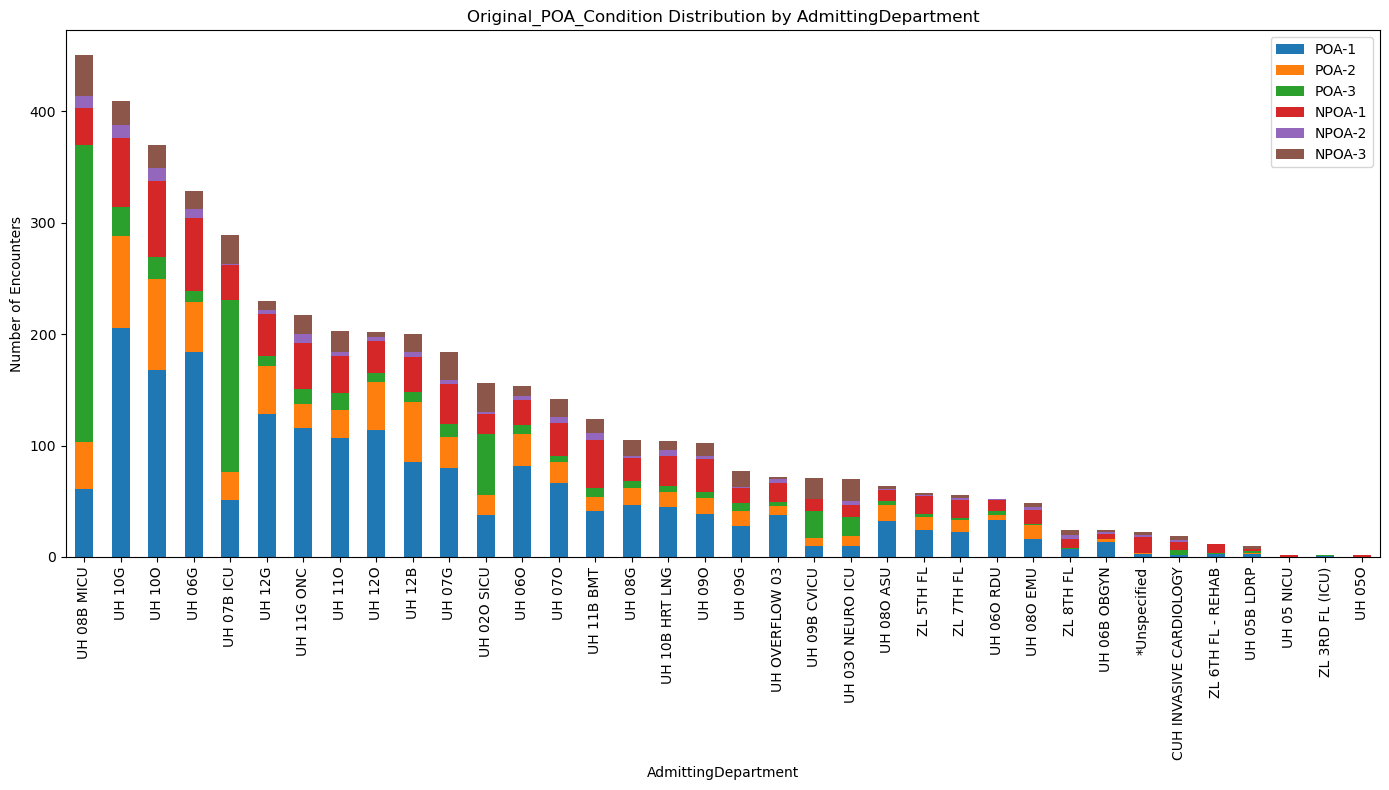

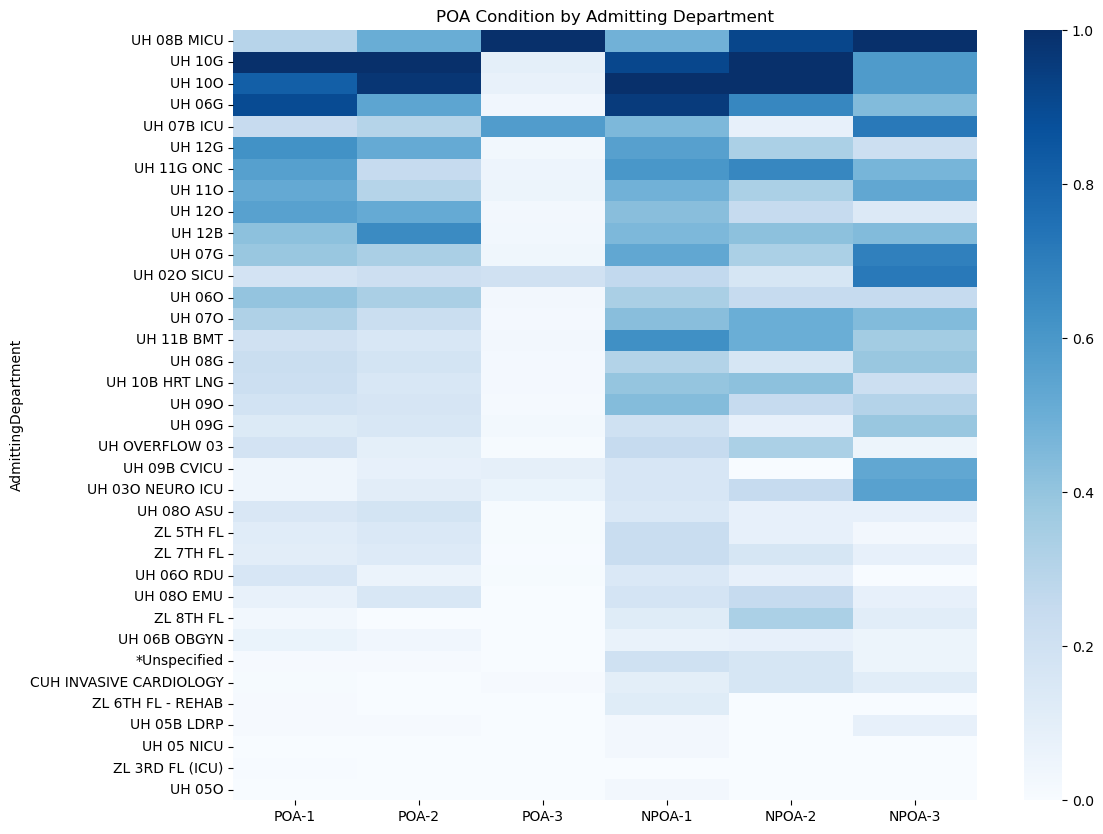

In [79]:
grb = df_final.group_by("EncounterEpicCsn").agg(
    pl.col("AdmittingDepartment").last(),
    pl.col("DischargeDepartment").last(),
    pl.col("AdmissionType").last(),
    pl.col("AdmissionSource").last(),
    pl.col("Original_POA_Condition").last(),
).group_by(["Original_POA_Condition", "AdmittingDepartment"]).agg(pl.len()).sort(by='len')
plot_per_group(df_final)

/tmp/ipykernel_3457621/4061055888.py:11: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  grb


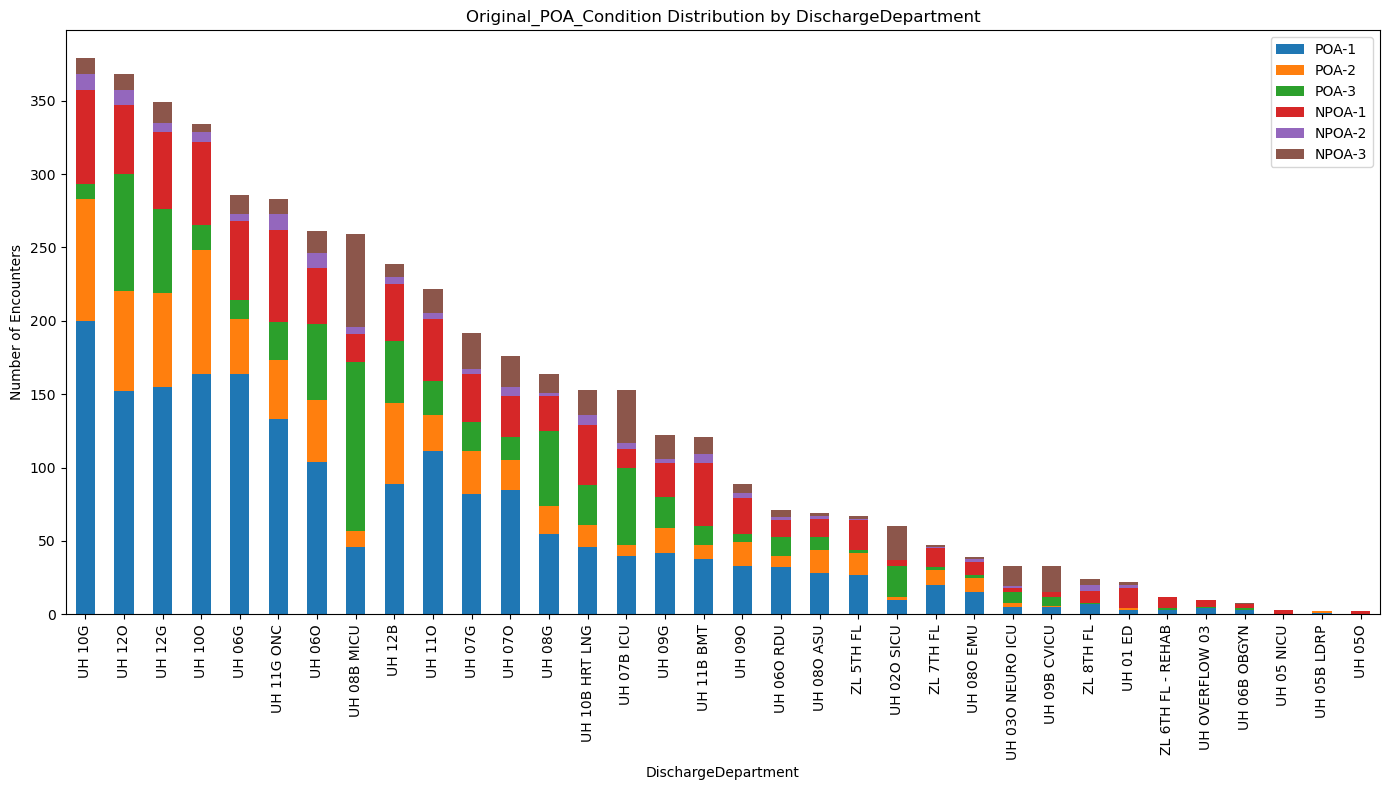

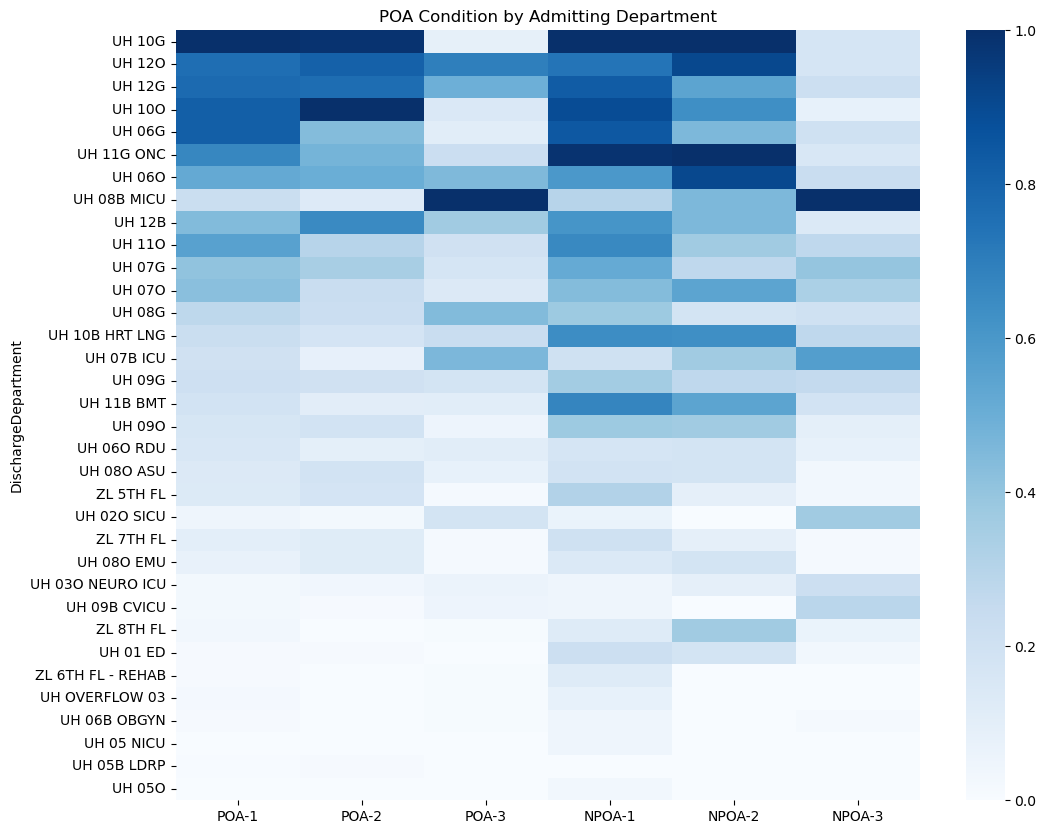

In [80]:
plot_per_group(df_final, "DischargeDepartment")

In [ ]:
plot_per_group(df_final, "AdmissionType")

36

Q2:
How long do patients spend in each sepsis severity score?

In [206]:
df_final.select(
    "EncounterEpicCsn",
    "Start_DateTime",
    "End_DateTime",
    "Start_DateTime_severity",
    "End_DateTime_severity",
    
)

EncounterEpicCsn,Start_DateTime,End_DateTime,Start_DateTime_severity,End_DateTime_severity
i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs]
717006646,2025-01-23 14:00:00,2025-01-24 06:15:00,2024-12-20 21:05:00,2025-04-17 09:00:00
733704050,2025-08-23 19:29:00,2025-08-23 23:00:00,2025-08-19 12:21:53,2025-08-29 10:00:00
695960811,2024-08-05 19:08:00,2024-08-08 15:49:00,2024-06-18 06:52:00,2024-09-12 22:04:00
724205477,2025-04-04 01:40:00,null,2025-04-04 13:55:00,2025-04-04 20:49:00
728105178,2025-06-16 12:18:00,2025-06-24 14:04:00,2025-06-17 14:42:00,2025-06-20 12:42:00
…,…,…,…,…
722954305,2025-03-16 07:00:00,2025-03-19 12:52:00,2025-03-14 16:02:15,2025-03-20 09:54:00
722697899,2025-03-06 23:00:00,2025-03-07 06:59:00,2025-03-05 13:01:00,2025-03-07 13:00:00
727206012,2025-05-16 08:07:00,2025-05-19 09:11:00,2025-05-17 19:15:00,2025-05-18 01:00:00


In [207]:
df_final.filter(pl.col("EncounterEpicCsn")==695960811).unique()

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,Start_DateTime,End_DateTime,SIRS,Start_DateTime_severity,End_DateTime_severity,Severe_Sepsis,Septic_Shock
i64,datetime[μs],str,str,str,str,str,str,i64,str,str,datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,datetime[μs],str,i64,i64,i64,f64,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,datetime[μs],datetime[μs],i64,i64
695960811,2024-09-13 06:45:00,"""Flowsheet""","""Systolic Blood Pressure""","""BLOOD PRESSURE""","""114""","""114/41""",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-09-13 00:36:00,2024-09-15 01:00:00,4.0,2024-09-13 02:51:33,2024-09-15 11:56:00,1,1
695960811,2024-04-05 09:08:00,"""Flowsheet""","""Gastrointestinal Assessment""","""CPM S25 R AS GASTROINTESTINAL …",null,"""X;appearance/characteristics;G…",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-03-26 20:30:00,2024-04-05 15:20:00,1.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-09-21 05:00:00,"""Flowsheet""","""Pulse""","""PULSE""","""87.0""","""87""",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-09-20 14:01:00,2024-09-21 05:33:00,3.0,2024-09-15 11:56:00,2024-10-28 11:26:00,0,1
695960811,2025-01-31 06:51:00,"""Lab Results""","""RDW""","""RDW""","""22.6""","""22.6""","""High""",92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2025-01-29 23:35:00,null,2.0,2024-12-16 19:23:00,null,0,1
695960811,2024-01-26 08:00:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""128/69""",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 1

In [208]:
df_events.with_columns(
    pl.col("Event_DateTime").str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f")
).sort(by="Event_DateTime").filter(pl.col("EncounterEpicCsn")==695960811)

/tmp/ipykernel_3367039/617856270.py:2: ChronoFormatWarning: Detected the pattern `.%f` in the chrono format string. This pattern should not be used to parse values after a decimal point. Use `%.f` instead. See the full specification: https://docs.rs/chrono/latest/chrono/format/strftime
  pl.col("Event_DateTime").str.strptime(dtype=pl.Datetime, format="%Y-%m-%d %H:%M:%S.%f")


EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag
i64,datetime[μs],str,str,str,str,str,str
695960811,2024-01-06 15:30:00,"""Flowsheet""","""Weight""","""WEIGHT/SCALE""","""3840.0""","""3840""",null
695960811,2024-01-06 15:30:00,"""Flowsheet""","""Pulse""","""PULSE""","""76.0""","""76""",null
695960811,2024-01-06 15:30:00,"""Flowsheet""","""Temperature""","""TEMPERATURE""","""97.3""","""97.3""",null
695960811,2024-01-06 15:30:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""","""18.0""","""18""",null
695960811,2024-01-06 15:30:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""105/50""",null
…,…,…,…,…,…,…,…
695960811,2025-02-04 03:29:32,"""Diagnosis Event""","""Billing Diagnosis""","""Acidosis, unspecified""",null,"""E87.20""",null
695960811,2025-02-04 03:29:32,"""Diagnosis Event""","""Billing Diagnosis""","""Elevation of levels of liver t…",null,"""R74.01""",null
695960811,2025-02-04 03:29:32,"""Diagnosis Event""","""Billing Diagnosis""","""Depression, unspecified""",null,"""F32.A""",null


In [209]:
df_events.filter(pl.col("EncounterEpicCsn")==695960811).unique()

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag
i64,str,str,str,str,str,str,str
695960811,"""2024-05-24 07:40:00.000""","""Flowsheet""","""O2 Delivery Room Air""","""CPM S25 R INV DEVICE.INV O2 DE…",null,"""room air""",null
695960811,"""2024-05-25 03:26:00.000""","""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""139/67""",null
695960811,"""2024-01-21 07:39:00.000""","""Flowsheet""","""Urine Output""","""URINE OUTPUT""","""100.0""","""100""",null
695960811,"""2024-02-15 14:50:00.000""","""Flowsheet""","""Respirations""","""RESPIRATIONS""","""15.0""","""15""",null
695960811,"""2024-08-15 20:00:00.000""","""Flowsheet""","""Respiratory Assessment""","""CPM S25 R AS RESPIRATORY WDL""",null,"""WDL""",null
…,…,…,…,…,…,…,…
695960811,"""2024-09-23 08:00:00.000""","""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""171/64""",null
695960811,"""2024-05-04 10:27:00.000""","""Lab Results""","""RDW""","""RDW""","""16.2""","""16.2""","""High"""
695960811,"""2024-04-16 19:15:00.000""","""Flowsheet""","""Temperature""","""TEMPERATURE""","""98.2""","""98.2""",null


In [213]:
df_final_811 = df_final.sort(by="Event_DateTime").filter(
    (pl.col("EncounterEpicCsn")==695960811)&
    (pl.col("Event_DateTime")>=dt.datetime(2024, 6, 17, 6, 28))&
    (pl.col("Event_DateTime")<=dt.datetime(2024, 6, 18, 6, 52))
    # (pl.col("Type")=="Lab Results")&(pl.col("Event_Grouper")=="eGFR")
)
df_final_811.shape

(77, 45)

In [162]:
df_sirs.with_columns(
    sepsis_1=(pl.col("SIRS")>=2).cast(pl.Int64)
).join_asof(
    df_sever.rename({"Start_DateTime":"Start_DateTime_severity"}), left_on="Start_DateTime", right_on="Start_DateTime_severity", by="EncounterEpicCsn",
    strategy="backward", suffix="_severity"
).filter(pl.col("End_DateTime").is_null() | (pl.col("Start_DateTime")<=pl.col("End_DateTime_severity"))).filter(pl.col("EncounterEpicCsn")==695960811)

/tmp/ipykernel_3367039/2124959908.py:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_sirs.with_columns(


EncounterEpicCsn,Start_DateTime,End_DateTime,SIRS,sepsis_1,Start_DateTime_severity,End_DateTime_severity,Severe_Sepsis,Septic_Shock
i64,datetime[μs],datetime[μs],f64,i64,datetime[μs],datetime[μs],i64,i64
695960811,2024-01-06 15:30:00,2024-01-06 18:22:00,0.0,0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-01-06 18:22:00,2024-01-11 13:34:00,1.0,0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-01-11 13:34:00,2024-01-12 13:59:00,2.0,1,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-01-12 13:59:00,2024-01-14 18:36:00,1.0,0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
695960811,2024-01-14 18:36:00,2024-01-14 18:42:00,2.0,1,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0
…,…,…,…,…,…,…,…,…
695960811,2024-12-14 01:00:00,2024-12-14 08:55:00,3.0,1,2024-11-01 07:02:00,2024-12-14 02:28:00,0,1
695960811,2024-12-14 08:55:00,2024-12-15 12:30:00,4.0,1,2024-12-14 02:28:00,2024-12-16 19:23:00,1,1
695960811,2024-12-15 12:30:00,2024-12-16 07:00:00,3.0,1,2024-12-14 02:28:00,2024-12-16 19:23:00,1,1


#### Searcing for 6 missing rows for encounter 695960811	
#### Conclusion
There are systolic blood pressure rows that do not exist in my flowsheet table. But the information (blood pressure) exists and its the same

In [ ]:
df_enc_811 = pl.read_csv(
    "./test_enc.csv", null_values=["Null", "null", "NULL", "none", "None"]
)

df_enc_811.with_columns(
    pl.col("Event_DateTime").str.strptime(pl.Datetime, "%m/%d/%y %H:%M")
)

In [170]:
ev_name = df_enc_811['Event_Name'].to_list()
ev_name_final = df_final_811['Event_Name'].to_list()
for ev_enc in ev_name:
    if ev_enc not in df_final_811['Event_Name'].to_list():
        print(ev_enc)

In [167]:
len(ev_name)

77

In [168]:
len(df_final_811['Event_Name'].to_list())

71

In [169]:
np.unique(ev_name,return_counts=True)

(array(['BLOOD PRESSURE', 'BUN', 'CHLORIDE',
        'CPM S25 R AS GASTROINTESTINAL WDL',
        'CPM S25 R AS GENITOURINARY WDL', 'CPM S25 R AS RESPIRATORY WDL',
        'CPM S25 R AS SC BRADEN SCORE', 'CPM S25 R AS SC SUM SCORE',
        'CPM S25 R INV DEVICE.INV O2 DEVICE', 'CREATININE',
        'EGFR CKD EPI CR', 'LEVOFLOXACIN 500 MG TAB', 'LYMPHS ABS',
        'LYMPHS PCT', 'MCHC', 'MONOS ABS', 'MONOS PCT', 'NEUTROS ABS',
        'NEUTROS PCT', 'NRBC', 'NRBC ABS', 'PLATELETS', 'PULSE', 'RBC',
        'RDW', 'RESPIRATIONS', 'SODIUM', 'TEMPERATURE', 'URINE OUTPUT',
        'UTSW CPM CUSTOM S25 R AS COGNITIVE/NEURO/BEHAVIORAL WDL',
        'UTSW CPM CUSTOM S25 R AS SKIN WDL', 'WBC'], dtype='<U55'),
 array([12,  2,  2,  2,  2,  2,  2,  2,  4,  2,  2,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  6,  1,  1,  6,  2,  6,  5,  2,  2,  1]))

In [171]:
np.unique(ev_name_final,return_counts=True)

(array(['BLOOD PRESSURE', 'BUN', 'CHLORIDE',
        'CPM S25 R AS GASTROINTESTINAL WDL',
        'CPM S25 R AS GENITOURINARY WDL', 'CPM S25 R AS RESPIRATORY WDL',
        'CPM S25 R AS SC BRADEN SCORE', 'CPM S25 R AS SC SUM SCORE',
        'CPM S25 R INV DEVICE.INV O2 DEVICE', 'CREATININE',
        'EGFR CKD EPI CR', 'LEVOFLOXACIN 500 MG TAB', 'LYMPHS ABS',
        'LYMPHS PCT', 'MCHC', 'MONOS ABS', 'MONOS PCT', 'NEUTROS ABS',
        'NEUTROS PCT', 'NRBC', 'NRBC ABS', 'PLATELETS', 'PULSE', 'RBC',
        'RDW', 'RESPIRATIONS', 'SODIUM', 'TEMPERATURE', 'URINE OUTPUT',
        'UTSW CPM CUSTOM S25 R AS COGNITIVE/NEURO/BEHAVIORAL WDL',
        'UTSW CPM CUSTOM S25 R AS SKIN WDL', 'WBC'], dtype='<U55'),
 array([6, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        6, 1, 1, 6, 2, 6, 5, 2, 2, 1]))

In [174]:
df_final_811.filter(pl.col("Event_Name")=="BLOOD PRESSURE").sort(by="Event_DateTime")

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,Start_DateTime,End_DateTime,SIRS,Start_DateTime_severity,End_DateTime_severity,Severe_Sepsis,Septic_Shock
i64,datetime[μs],str,str,str,str,str,str,i64,str,str,datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,datetime[μs],str,i64,i64,i64,f64,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,datetime[μs],datetime[μs],i64,i64
695960811,2024-06-17 07:14:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""145/56""",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-06-08 23:32:00,2024-06-19 10:47:00,1.0,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
695960811,2024-06-17 12:26:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""134/56""",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-06-08 23:32:00,2024-06-19 10:47:00,1.0,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
695960811,2024-06-17 15:25:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""124/50""",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-06-08 23:32:00,2024-06-19 10:47:00,1.0,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
695960811,2024-06-17 19:29:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""118/48""",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Aplastic anemia (*)""","""Myelodysplastic syndrome, unsp…","""Resection of Left Large Intest…",0,"""NPOA-3""","""NPOA-3""",2024-04-05 09:12:33,"""IV Antibiotics + Blood Culture…",130,17,80,1.407647,14.489231,1.140426,58.494118,1.490202,2024-06-08 23:32:00,2024-06-19 10:47:00,1.0,2024-06-17 06:28:00,2024-06-18 06:52:00,1,0
695960811,2024-06-17 22:50:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""118/45""",null,92882623,"""2024-01-06""","""2025-02-02""",2024-01-06 15:26:00,2024-01-06 20:15:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 11O""","""

In [175]:
df_enc_811.filter(pl.col("Event_Name")=="BLOOD PRESSURE").sort(by="Event_DateTime")

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag
i64,str,str,str,str,f64,str,str
695960811,"""6/17/24 12:26""","""Flowsheet""","""Systolic Blood Pressure""","""BLOOD PRESSURE""",134.0,"""134/56""",null
695960811,"""6/17/24 12:26""","""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""134/56""",null
695960811,"""6/17/24 15:25""","""Flowsheet""","""Systolic Blood Pressure""","""BLOOD PRESSURE""",124.0,"""124/50""",null
695960811,"""6/17/24 15:25""","""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""124/50""",null
695960811,"""6/17/24 19:29""","""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""118/48""",null
…,…,…,…,…,…,…,…
695960811,"""6/17/24 22:50""","""Flowsheet""","""Systolic Blood Pressure""","""BLOOD PRESSURE""",118.0,"""118/45""",null
695960811,"""6/17/24 7:14""","""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""145/56""",null
695960811,"""6/17/24 7:14""","""Flowsheet""","""Systolic Blood Pressure""","""BLOOD PRESSURE""",145.0,"""145/56""",null


### Transition state diagram between sepsis severity scores

In [ ]:
df_encs_sirs = df_sirs.with_columns(
    (pl.col("End_DateTime")-pl.col("Start_DateTime")).dt.total_hours(fractional=True).alias("sirs_period_hrs")
).sort(by='Start_DateTime').drop_nulls(subset=["Start_DateTime"]).join(
    df_enc, on="EncounterEpicCsn"
)

df_encs_severe = df_sirs.with_columns(
    (pl.col("End_DateTime")-pl.col("Start_DateTime")).dt.total_hours(fractional=True).alias("severity_period_hrs")
).sort(by='Start_DateTime').drop_nulls(subset=["Start_DateTime"]).join(
    df_enc, on="EncounterEpicCsn"
)


In [232]:
df_sirs = df_sirs.with_columns(
    (pl.col("End_DateTime")-pl.col("Start_DateTime")).dt.total_hours(fractional=True).alias("severity_period_hrs"),
    sepsis_1=(pl.col("SIRS")>=2).cast(pl.Int64)
).sort(by='Start_DateTime').drop_nulls(subset=['Start_DateTime', 'End_DateTime'])

In [244]:
df_sever = df_sever.with_columns(
    (pl.col("End_DateTime")-pl.col("Start_DateTime")).dt.total_hours(fractional=True).alias("severity_period_hrs"),
    pl.when(pl.col("Septic_Shock")==1).then(pl.lit(2)).otherwise(pl.col("Septic_Shock")).alias("septic_shock_2"),

).with_columns(total=(pl.col("septic_shock_2")+pl.col("Severe_Sepsis"))).sort(by='Start_DateTime').drop_nulls(subset=['Start_DateTime', "End_DateTime"])
df_sever

EncounterEpicCsn,Start_DateTime,End_DateTime,Severe_Sepsis,Septic_Shock,severity_period_hrs,septic_shock_2,total
i64,datetime[μs],datetime[μs],i64,i64,f64,i64,i64
695960811,2024-01-06 15:30:00,2024-06-17 06:28:00,0,0,3902.966667,0,0
699476058,2024-04-30 06:15:00,2024-04-30 10:26:00,0,0,4.183333,0,0
699476058,2024-04-30 10:26:00,2024-04-30 21:58:00,1,0,11.533333,0,1
699476058,2024-04-30 21:58:00,2024-04-30 22:05:00,1,1,0.116667,2,3
699476058,2024-04-30 22:05:00,2024-04-30 22:16:00,1,0,0.183333,0,1
…,…,…,…,…,…,…,…
745052798,2026-01-29 19:00:00,2026-01-29 21:00:00,0,0,2.0,0,0
745052798,2026-01-29 21:00:00,2026-01-29 23:00:00,0,1,2.0,2,2
745138325,2026-01-30 09:24:00,2026-01-30 09:55:00,0,1,0.516667,2,2


In [245]:
boundaries = (
    pl.concat([
        df_sirs.select(["EncounterEpicCsn", pl.col("Start_DateTime").alias("t")]),
        df_sirs.select(["EncounterEpicCsn", pl.col("End_DateTime").alias("t")]),
        df_sever.select(["EncounterEpicCsn", pl.col("Start_DateTime").alias("t")]),
        df_sever.select(["EncounterEpicCsn", pl.col("End_DateTime").alias("t")]),
    ])
    .unique()
    .sort(["EncounterEpicCsn", "t"])
)
boundaries

EncounterEpicCsn,t
i64,datetime[μs]
695960811,2024-01-06 15:30:00
695960811,2024-01-06 18:22:00
695960811,2024-01-11 13:34:00
695960811,2024-01-12 13:59:00
695960811,2024-01-14 18:36:00
…,…
745328066,2026-01-29 11:28:00
745328066,2026-01-29 12:45:00
745328066,2026-01-29 18:25:00


In [246]:
segments = (
    boundaries
    .with_columns(pl.col("t").shift(-1).over("EncounterEpicCsn").alias("t_next"))
    .filter(pl.col("t_next").is_not_null() & (pl.col("t_next") > pl.col("t")))
    .rename({"t": "Segment_Start", "t_next": "Segment_End"})
)
segments

EncounterEpicCsn,Segment_Start,Segment_End
i64,datetime[μs],datetime[μs]
695960811,2024-01-06 15:30:00,2024-01-06 18:22:00
695960811,2024-01-06 18:22:00,2024-01-11 13:34:00
695960811,2024-01-11 13:34:00,2024-01-12 13:59:00
695960811,2024-01-12 13:59:00,2024-01-14 18:36:00
695960811,2024-01-14 18:36:00,2024-01-14 18:42:00
…,…,…
745328066,2026-01-29 09:25:00,2026-01-29 11:28:00
745328066,2026-01-29 11:28:00,2026-01-29 12:45:00
745328066,2026-01-29 12:45:00,2026-01-29 18:25:00


In [247]:
df_sirs_sorted = df_sirs.sort(["EncounterEpicCsn", "Start_DateTime"])
seg_with_a = (
    segments
    .join_asof(
        df_sirs_sorted,
        left_on="Segment_Start",
        right_on="Start_DateTime",
        by="EncounterEpicCsn",
        strategy="backward",
    )
    .with_columns(
        pl.when(
            (pl.col("Segment_Start") >= pl.col("Start_DateTime")) &
            (pl.col("Segment_Start") <  pl.col("End_DateTime"))
        ).then(pl.col("SIRS")).otherwise(pl.lit(None)).alias("SIRS")
    )
    .select(["EncounterEpicCsn", "Segment_Start", "Segment_End", "SIRS"])
)
seg_with_a

/tmp/ipykernel_3367039/515320107.py:3: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  segments


EncounterEpicCsn,Segment_Start,Segment_End,SIRS
i64,datetime[μs],datetime[μs],f64
695960811,2024-01-06 15:30:00,2024-01-06 18:22:00,0.0
695960811,2024-01-06 18:22:00,2024-01-11 13:34:00,1.0
695960811,2024-01-11 13:34:00,2024-01-12 13:59:00,2.0
695960811,2024-01-12 13:59:00,2024-01-14 18:36:00,1.0
695960811,2024-01-14 18:36:00,2024-01-14 18:42:00,2.0
…,…,…,…
745328066,2026-01-29 09:25:00,2026-01-29 11:28:00,0.0
745328066,2026-01-29 11:28:00,2026-01-29 12:45:00,0.0
745328066,2026-01-29 12:45:00,2026-01-29 18:25:00,1.0


In [248]:
df_sever_sorted = df_sever.sort(["EncounterEpicCsn", "Start_DateTime"])
seg_with_ab = (
    seg_with_a
    .join_asof(
        df_sever_sorted,
        left_on="Segment_Start",
        right_on="Start_DateTime",
        by="EncounterEpicCsn",
        strategy="backward",
    )
    .with_columns(
        pl.when(
            (pl.col("Segment_Start") >= pl.col("Start_DateTime")) &
            (pl.col("Segment_Start") <  pl.col("End_DateTime"))
        ).then(pl.col("total")).otherwise(pl.lit(None)).alias("total")
    )
    .select(["EncounterEpicCsn", "Segment_Start", "Segment_End", "SIRS", "total"])
    .with_columns(
        (pl.col("SIRS").is_not_null() & pl.col("total").is_not_null()).alias("overlap_flag")
    )
    # optional: drop segments where neither state is active
    .filter(pl.col("SIRS").is_not_null() | pl.col("total").is_not_null())
)


/tmp/ipykernel_3367039/2589583832.py:3: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  seg_with_a


In [250]:
seg_with_ab.fill_null(0)

EncounterEpicCsn,Segment_Start,Segment_End,SIRS,total,overlap_flag
i64,datetime[μs],datetime[μs],f64,i64,bool
695960811,2024-01-06 15:30:00,2024-01-06 18:22:00,0.0,0,true
695960811,2024-01-06 18:22:00,2024-01-11 13:34:00,1.0,0,true
695960811,2024-01-11 13:34:00,2024-01-12 13:59:00,2.0,0,true
695960811,2024-01-12 13:59:00,2024-01-14 18:36:00,1.0,0,true
695960811,2024-01-14 18:36:00,2024-01-14 18:42:00,2.0,0,true
…,…,…,…,…,…
745328066,2026-01-29 09:25:00,2026-01-29 11:28:00,0.0,0,true
745328066,2026-01-29 11:28:00,2026-01-29 12:45:00,0.0,1,true
745328066,2026-01-29 12:45:00,2026-01-29 18:25:00,1.0,1,true


In [251]:
import polars as pl

# 0) Rename interval columns so both sets survive the joins
df_sirs2 = df_sirs.select([
    "EncounterEpicCsn",
    pl.col("Start_DateTime").alias("SIRS_Start"),
    pl.col("End_DateTime").alias("SIRS_End"),
    "SIRS",
]).sort(["EncounterEpicCsn", "SIRS_Start"])

df_sever = df_sever.select([
    "EncounterEpicCsn",
    pl.col("Start_DateTime").alias("total_Start"),
    pl.col("End_DateTime").alias("total_End"),
    "total",
]).sort(["EncounterEpicCsn", "total_Start"])


# 1) Boundaries: all starts and ends from both tables
boundaries = (
    pl.concat([
        df_sirs2.select(["EncounterEpicCsn", pl.col("SIRS_Start").alias("t")]),
        df_sirs2.select(["EncounterEpicCsn", pl.col("SIRS_End").alias("t")]),
        df_sever.select(["EncounterEpicCsn", pl.col("total_Start").alias("t")]),
        df_sever.select(["EncounterEpicCsn", pl.col("total_End").alias("t")]),
    ])
    .unique()
    .sort(["EncounterEpicCsn", "t"])
)

# 2) Segments: consecutive [t_i, t_{i+1})
segments = (
    boundaries
    .with_columns(pl.col("t").shift(-1).over("EncounterEpicCsn").alias("t_next"))
    .filter(pl.col("t_next").is_not_null() & (pl.col("t_next") > pl.col("t")))
    .rename({"t": "Segment_Start", "t_next": "Segment_End"})
)

# 3) Attach SIRS interval that is active at Segment_Start
seg_with_sirs = (
    segments
    .join_asof(
        df_sirs2,
        left_on="Segment_Start",
        right_on="SIRS_Start",
        by="EncounterEpicCsn",
        strategy="backward",
    )
    .with_columns(
        pl.when(
            (pl.col("Segment_Start") >= pl.col("SIRS_Start")) &
            (pl.col("Segment_Start") <  pl.col("SIRS_End"))
        ).then(pl.col("SIRS")).otherwise(pl.lit(None)).alias("SIRS")
    )
)

# 4) Attach total interval that is active at Segment_Start
seg_with_ab = (
    seg_with_sirs
    .join_asof(
        df_sever,
        left_on="Segment_Start",
        right_on="total_Start",
        by="EncounterEpicCsn",
        strategy="backward",
    )
    .with_columns(
        pl.when(
            (pl.col("Segment_Start") >= pl.col("total_Start")) &
            (pl.col("Segment_Start") <  pl.col("total_End"))
        ).then(pl.col("total")).otherwise(pl.lit(None)).alias("total")
    )
    .with_columns(
        (pl.col("SIRS").is_not_null() & pl.col("total").is_not_null()).alias("overlap_flag")
    )
    # Optional: drop segments where neither is active
    .filter(pl.col("SIRS").is_not_null() | pl.col("total").is_not_null())
)

# seg_with_ab now contains:
# Segment_Start, Segment_End, SIRS, total, plus SIRS_Start/SIRS_End and total_Start/total_End


/tmp/ipykernel_3367039/4068460594.py:41: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  segments
/tmp/ipykernel_3367039/4068460594.py:59: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  seg_with_sirs


In [252]:
seg_with_ab

EncounterEpicCsn,Segment_Start,Segment_End,SIRS_Start,SIRS_End,SIRS,total_Start,total_End,total,overlap_flag
i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],f64,datetime[μs],datetime[μs],i64,bool
695960811,2024-01-06 15:30:00,2024-01-06 18:22:00,2024-01-06 15:30:00,2024-01-06 18:22:00,0.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true
695960811,2024-01-06 18:22:00,2024-01-11 13:34:00,2024-01-06 18:22:00,2024-01-11 13:34:00,1.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true
695960811,2024-01-11 13:34:00,2024-01-12 13:59:00,2024-01-11 13:34:00,2024-01-12 13:59:00,2.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true
695960811,2024-01-12 13:59:00,2024-01-14 18:36:00,2024-01-12 13:59:00,2024-01-14 18:36:00,1.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true
695960811,2024-01-14 18:36:00,2024-01-14 18:42:00,2024-01-14 18:36:00,2024-01-14 18:42:00,2.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true
…,…,…,…,…,…,…,…,…,…
745328066,2026-01-29 09:25:00,2026-01-29 11:28:00,2026-01-29 09:25:00,2026-01-29 12:45:00,0.0,2026-01-29 09:25:00,2026-01-29 11:28:00,0,true
745328066,2026-01-29 11:28:00,2026-01-29 12:45:00,2026-01-29 09:25:00,2026-01-29 12:45:00,0.0,2026-01-29 11:28:00,2026-01-30 19:39:00,1,true
745328066,2026-01-29 12:45:00,2026-01-29 18:25:00,2026-01-29 12:45:00,2026-01-29 18:25:00,1.0,2026-01-29 11:28:00,2026-01-30 19:39:00,1,true


In [253]:
seg_with_ab = seg_with_ab.with_columns(
    pl.when(pl.col("SIRS_Start") < pl.col("total_Start")).then(pl.lit("SIRS_then_total"))
      .when(pl.col("total_Start") < pl.col("SIRS_Start")).then(pl.lit("total_then_SIRS"))
      .otherwise(pl.lit("same_start"))
      .alias("start_order"),

    pl.when(pl.col("SIRS_End") < pl.col("total_End")).then(pl.lit("SIRS_then_total"))
      .when(pl.col("total_End") < pl.col("SIRS_End")).then(pl.lit("total_then_SIRS"))
      .otherwise(pl.lit("same_end"))
      .alias("end_order"),

    pl.when((pl.col("SIRS_Start") <= pl.col("total_Start")) & (pl.col("SIRS_End") >= pl.col("total_End")))
      .then(pl.lit("SIRS_contains_total"))
      .when((pl.col("total_Start") <= pl.col("SIRS_Start")) & (pl.col("total_End") >= pl.col("SIRS_End")))
      .then(pl.lit("total_contains_SIRS"))
      .when((pl.col("SIRS_Start") < pl.col("total_Start")) & (pl.col("SIRS_End") < pl.col("total_End")))
      .then(pl.lit("SIRS_starts_first_total_ends_last"))
      .when((pl.col("total_Start") < pl.col("SIRS_Start")) & (pl.col("total_End") < pl.col("SIRS_End")))
      .then(pl.lit("total_starts_first_SIRS_ends_last"))
      .otherwise(pl.lit(None))
      .alias("overlap_pattern"),
).with_columns(
    # keep these labels only on real overlaps
    pl.when(pl.col("overlap_flag")).then(pl.col("start_order")).otherwise(pl.lit(None)).alias("start_order"),
    pl.when(pl.col("overlap_flag")).then(pl.col("end_order")).otherwise(pl.lit(None)).alias("end_order"),
    pl.when(pl.col("overlap_flag")).then(pl.col("overlap_pattern")).otherwise(pl.lit(None)).alias("overlap_pattern"),
)


In [254]:
seg_with_ab

EncounterEpicCsn,Segment_Start,Segment_End,SIRS_Start,SIRS_End,SIRS,total_Start,total_End,total,overlap_flag,start_order,end_order,overlap_pattern
i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],f64,datetime[μs],datetime[μs],i64,bool,str,str,str
695960811,2024-01-06 15:30:00,2024-01-06 18:22:00,2024-01-06 15:30:00,2024-01-06 18:22:00,0.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true,"""same_start""","""SIRS_then_total""","""total_contains_SIRS"""
695960811,2024-01-06 18:22:00,2024-01-11 13:34:00,2024-01-06 18:22:00,2024-01-11 13:34:00,1.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true,"""total_then_SIRS""","""SIRS_then_total""","""total_contains_SIRS"""
695960811,2024-01-11 13:34:00,2024-01-12 13:59:00,2024-01-11 13:34:00,2024-01-12 13:59:00,2.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true,"""total_then_SIRS""","""SIRS_then_total""","""total_contains_SIRS"""
695960811,2024-01-12 13:59:00,2024-01-14 18:36:00,2024-01-12 13:59:00,2024-01-14 18:36:00,1.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true,"""total_then_SIRS""","""SIRS_then_total""","""total_contains_SIRS"""
695960811,2024-01-14 18:36:00,2024-01-14 18:42:00,2024-01-14 18:36:00,2024-01-14 18:42:00,2.0,2024-01-06 15:30:00,2024-06-17 06:28:00,0,true,"""total_then_SIRS""","""SIRS_then_total""","""total_contains_SIRS"""
…,…,…,…,…,…,…,…,…,…,…,…,…
745328066,2026-01-29 09:25:00,2026-01-29 11:28:00,2026-01-29 09:25:00,2026-01-29 12:45:00,0.0,2026-01-29 09:25:00,2026-01-29 11:28:00,0,true,"""same_start""","""total_then_SIRS""","""SIRS_contains_total"""
745328066,2026-01-29 11:28:00,2026-01-29 12:45:00,2026-01-29 09:25:00,2026-01-29 12:45:00,0.0,2026-01-29 11:28:00,2026-01-30 19:39:00,1,true,"""SIRS_then_total""","""SIRS_then_total""","""SIRS_starts_first_total_ends_l…"
745328066,2026-01-29 12:45:00,2026-01-29 18:25:00,2026-01-29 12:45:00,2026-01-29 18:25:00,1.0,2026-01-29 11:28:00,2026-01-30 19:39:00,1,true,"""total_then_SIRS""","""SIRS_then_total""","""total_contains_SIRS"""


In [255]:
import polars as pl

# Assume seg_with_ab columns:
# EncounterEpicCsn, Segment_Start, Segment_End, SIRS (0/1 or null), total (0..3 or null)

df = (
    seg_with_ab
    .with_columns([
        # duration in hours (change unit if you prefer)
        (pl.col("Segment_End") - pl.col("Segment_Start")).dt.total_seconds().truediv(3600).alias("dur_hrs"),

        # If null means "not active", map to 0 or keep null depending on your meaning
        pl.col("SIRS").fill_null(0).cast(pl.Int8).alias("SIRS"),
        pl.col("total").fill_null(0).cast(pl.Int8).alias("total"),

        # combined state label
        pl.format("SIRS={}|total={}", pl.col("SIRS"), pl.col("total")).alias("state"),
    ])
    .sort(["EncounterEpicCsn", "Segment_Start"])
)

# Episode id increments when state changes
df = df.with_columns(
    (
        (pl.col("state") != pl.col("state").shift(1))
        .fill_null(True)
        .cast(pl.Int64)
        .cum_sum()
        .over("EncounterEpicCsn")
    ).alias("episode_id")
)

episodes = (
    df.group_by(["EncounterEpicCsn", "episode_id"])
      .agg([
          pl.col("Segment_Start").min().alias("Start"),
          pl.col("Segment_End").max().alias("End"),
          pl.col("dur_hrs").sum().alias("dur_hrs"),
          pl.col("SIRS").first().alias("SIRS"),
          pl.col("total").first().alias("total"),
          pl.col("state").first().alias("state"),
      ])
      .sort(["EncounterEpicCsn", "Start"])
)


In [256]:
state_time = (
    episodes
    .group_by("state")
    .agg([
        pl.len().alias("n_episodes"),
        pl.col("dur_hrs").sum().alias("total_hours"),
        pl.col("dur_hrs").mean().alias("mean_hours"),
        pl.col("dur_hrs").median().alias("median_hours"),
    ])
    .sort("total_hours", descending=True)
)


In [257]:
transitions = (
    episodes
    .with_columns([
        pl.col("state").shift(-1).over("EncounterEpicCsn").alias("next_state"),
        pl.col("Start").shift(-1).over("EncounterEpicCsn").alias("next_start"),
    ])
    .filter(pl.col("next_state").is_not_null() & (pl.col("next_state") != pl.col("state")))
    .group_by(["state", "next_state"])
    .agg([
        pl.len().alias("n_transitions"),
        pl.col("dur_hrs").sum().alias("hours_in_source_before_transition"),
        pl.col("dur_hrs").mean().alias("mean_hours_in_source_before_transition"),
    ])
    .sort("n_transitions", descending=True)
)


In [259]:
state_time = state_time.filter(pl.col("state").is_not_null())
transitions = transitions.filter(
    pl.col("state").is_not_null() &
    pl.col("next_state").is_not_null()
)


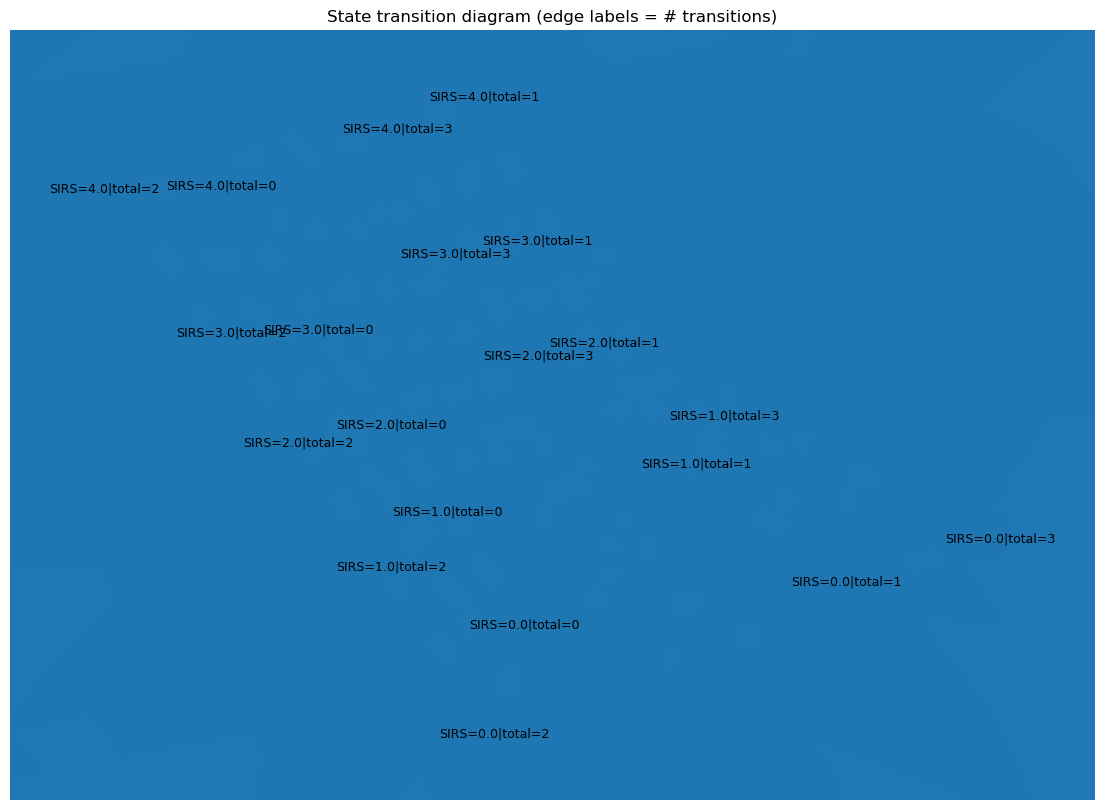

In [260]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert Polars to python lists
nodes = state_time.select(["state", "total_hours"]).to_dicts()
edges = transitions.select(["state", "next_state", "n_transitions"]).to_dicts()

G = nx.DiGraph()

for n in nodes:
    G.add_node(n["state"], total_hours=n["total_hours"])

for e in edges:
    G.add_edge(e["state"], e["next_state"], weight=e["n_transitions"])

pos = nx.spring_layout(G, seed=0)

# Node sizes proportional to total_hours
sizes = [max(100, G.nodes[n].get("total_hours", 0.0) * 50) for n in G.nodes]

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9)

# Edge widths proportional to transition counts
weights = [G[u][v]["weight"] for u, v in G.edges]
widths = [max(0.5, w * 0.2) for w in weights]
nx.draw_networkx_edges(G, pos, width=widths, arrows=True, alpha=0.6)

# Optional: edge labels
edge_labels = {(u, v): G[u][v]["weight"] for u, v in G.edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.axis("off")
plt.title("State transition diagram (edge labels = # transitions)")
plt.show()


In [261]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for n in nodes:
    G.add_node(n["state"], total_hours=n["total_hours"])

for e in edges:
    G.add_edge(e["state"], e["next_state"], weight=e["n_transitions"])

# Build structured positions
pos = {}
for node in G.nodes:
    # Parse state
    sirs = int(node.split("|")[0].split("=")[1])
    total = int(node.split("|")[1].split("=")[1])
    pos[node] = (total, sirs)  # x=total, y=SIRS

plt.figure(figsize=(12, 10))

sizes = [max(100, G.nodes[n]["total_hours"] * 20) for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=sizes)

weights = [G[u][v]["weight"] for u, v in G.edges]
widths = [max(0.3, w * 0.1) for w in weights]

nx.draw_networkx_edges(G, pos, width=widths, arrows=True, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.xlabel("total")
plt.ylabel("SIRS")
plt.title("Structured State Transition Diagram")
plt.grid(True)
plt.show()


ValueError: invalid literal for int() with base 10: '2.0'

In [263]:
int(node.split("|")[0].split("=")[1])

ValueError: invalid literal for int() with base 10: '2.0'